# Классификация клиентов интернет-магазина одежды

## Описание проекта

Интернет-магазин проводит рекламные рассылки и планирует будущие продажи.
Цель проекта — построить модель бинарной классификации, которая предсказывает
вероятность покупки клиентом в течение 90 дней. Модель должна позволять выделить
пользователей, готовых совершить покупку в ближайшее время, чтобы использовать
эту информацию для планирования продаж и оптимизации бизнес-процессов.

## Данные

| Файл | Содержание |
|---|---|
| `apparel-purchases.csv` | История покупок клиентов |
| `apparel-messages.csv` | История рекламных рассылок |
| `apparel-target_binary.csv` | Целевая переменная (1 — покупка в течение 90 дней) |
| `full_campaign_daily_event.csv` | Ежедневная статистика кампаний |
| `full_campaign_daily_event_channel.csv` | Статистика кампаний по каналам |

**Объём выборки:** 49 849 клиентов, из которых 961 (1.93%) совершили
целевое действие. Точка отсечения CUTOFF = 2024-02-16: признаки строятся
по событиям до CUTOFF, целевая переменная — по событиям в окне
2024-02-16 → 2024-05-16. Разделение исключает утечку данных из
будущего и воспроизводит реальную ситуацию применения модели.

## Метрика качества

Основная метрика — **ROC-AUC**. Выбор обусловлен сильным дисбалансом
классов (1.93% позитивного класса): accuracy и F1 дают искажённую картину
при таком соотношении, тогда как ROC-AUC устойчив к дисбалансу и измеряет
способность модели ранжировать клиентов по вероятности покупки.

## Содержание

0. [Конфигурация и импорты](#sec0)
1. [Загрузка и первичный анализ данных](#sec1)
2. [Валидация ключевых констант](#sec2)
3. [Исследовательский анализ данных](#sec3)
4. [Инжиниринг признаков](#sec4)
5. [Обучение и оценка моделей](#sec5)
6. [Выводы](#sec6)

<a id="sec0"></a>
## 0. Конфигурация и импорты

In [1]:
# =============================================================================
# Импорты
# =============================================================================

# 1. Стандартная библиотека
import ast
import os
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# 2. Сторонние пакеты
import duckdb
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import phik
import psutil
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.calibration import calibration_curve
from sklearn.ensemble import StackingClassifier
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_recall_curve, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

optuna.logging.set_verbosity(optuna.logging.WARNING)
# ── Рабочая директория ────────────────────────────────────────────────────────
def _find_project_root(marker: str = "data") -> Path:
    """Поднимается вверх по дереву директорий до папки с marker."""
    for parent in [Path.cwd()] + list(Path.cwd().parents):
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Не найдена папка '{marker}' в дереве директорий")

PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)

# ── Пути к данным ─────────────────────────────────────────────────────────────
DATA_DIR = Path("data")

PATH_PURCHASES   = DATA_DIR / "apparel-purchases.csv"
PATH_MESSAGES    = DATA_DIR / "apparel-messages.csv"
PATH_TARGET      = DATA_DIR / "apparel-target_binary.csv"
PATH_CAMPAIGN    = DATA_DIR / "full_campaign_daily_event.csv"
PATH_CAMPAIGN_CH = DATA_DIR / "full_campaign_daily_event_channel.csv"

# ── Константы проекта ─────────────────────────────────────────────────────────
CUTOFF       = pd.Timestamp("2024-02-16")
TARGET_END   = pd.Timestamp("2024-05-16")
CHUNKSIZE    = 1_000_000
RANDOM_STATE = 42

# ── Валидационные константы (из условия задачи) ───────────────────────────────
N_CLIENTS_EXPECTED   = 49_849
N_POSITIVES_EXPECTED = 961

# ── Проверка наличия файлов ───────────────────────────────────────────────────
print(f"Project root: {PROJECT_ROOT}\n")

for path in [PATH_PURCHASES, PATH_MESSAGES, PATH_TARGET,
             PATH_CAMPAIGN, PATH_CAMPAIGN_CH]:
    status = "✓" if path.exists() else "✗ NOT FOUND"
    print(f"  {status}  {path.name}")

print("\nimport OK")

Project root: /Users/agnat/Library/CloudStorage/GoogleDrive-agnatsh@gmail.com/My Drive/DS Learning/Practicum/Projects/YP06_Apparel-Marketing-Classification

  ✓  apparel-purchases.csv
  ✓  apparel-messages.csv
  ✓  apparel-target_binary.csv
  ✓  full_campaign_daily_event.csv
  ✓  full_campaign_daily_event_channel.csv

import OK


<a id="sec1"></a>
## 1. Загрузка и первичный анализ данных


In [2]:
NOTEBOOK_START_TIME = time.perf_counter()

In [3]:
# =============================================================================
# Первичный осмотр файлов
# =============================================================================

def _file_info(path: Path) -> dict:
    """Размер, кол-во строк и столбцов без загрузки файла в память."""
    size_mb = path.stat().st_size / 1024 ** 2
    cols    = pd.read_csv(path, nrows=0).columns.tolist()
    with open(path, "r") as f:
        n_rows = sum(1 for _ in f) - 1  # -1 для заголовка
    return {"size_mb": size_mb, "n_rows": n_rows, "n_cols": len(cols)}

# ── Сводная таблица ───────────────────────────────────────────────────────────
print("=== Сводная информация о файлах ===\n")
print(f"  {'Файл':<45} {'Размер':>10} {'Строк':>12} {'Столбцов':>10}")
print("  " + "-" * 80)

for path in [PATH_PURCHASES, PATH_MESSAGES, PATH_TARGET,
             PATH_CAMPAIGN, PATH_CAMPAIGN_CH]:
    info = _file_info(path)
    print(f"  {path.name:<45} {info['size_mb']:>8.1f} MB "
          f"{info['n_rows']:>12,} {info['n_cols']:>10}")

# ── Структура каждого файла (первые 3 строки) ─────────────────────────────────
print("\n\n=== Структура файлов ===")
for path in [PATH_PURCHASES, PATH_MESSAGES, PATH_TARGET,
             PATH_CAMPAIGN, PATH_CAMPAIGN_CH]:
    print(f"\n── {path.name} ──")
    df_peek = pd.read_csv(path, nrows=3)
    print(df_peek)
    print(f"\ndtypes:\n{df_peek.dtypes}")
    print("-" * 60)

FILES_INFO = {}
for path in [PATH_PURCHASES, PATH_MESSAGES, PATH_TARGET,
             PATH_CAMPAIGN, PATH_CAMPAIGN_CH]:
    FILES_INFO[path.name] = _file_info(path)

print("\nCell 4 OK")

=== Сводная информация о файлах ===

  Файл                                              Размер        Строк   Столбцов
  --------------------------------------------------------------------------------
  apparel-purchases.csv                             20.8 MB      202,208          6
  apparel-messages.csv                            1348.5 MB   12,739,798          7
  apparel-target_binary.csv                          1.0 MB       49,849          2
  full_campaign_daily_event.csv                      7.8 MB      131,072         24
  full_campaign_daily_event_channel.csv             10.8 MB      131,072         36


=== Структура файлов ===

── apparel-purchases.csv ──
             client_id  quantity   price              category_ids  \
0  1515915625468169594         1  1999.0  ['4', '28', '57', '431']   
1  1515915625468169594         1  2499.0  ['4', '28', '57', '431']   
2  1515915625471138230         1  6499.0  ['4', '28', '57', '431']   

         date                           

In [4]:
N_MESSAGES_ROWS_EXPECTED = 12_739_798

<a id="sec2"></a>
## 2. Валидация ключевых констант

In [5]:
# =============================================================================
# Валидация ключевых констант
# =============================================================================

target = pd.read_csv(PATH_TARGET)

n_clients   = len(target)
n_positives = int(target["target"].sum())
pos_rate    = n_positives / n_clients
n_msg_rows  = FILES_INFO[PATH_MESSAGES.name]["n_rows"]

print("=== Валидация констант ===\n")
print(f"  Клиентов:         {n_clients:>10,}  (ожидается {N_CLIENTS_EXPECTED:,})")
print(f"  Позитивный отклик:        {n_positives:>10,}  (ожидается {N_POSITIVES_EXPECTED:,})")
print(f"  Доля позитивных реакций:    {pos_rate:>10.4f}  (ожидается ~0.0193)")
print(f"  Строк messages:   {n_msg_rows:>10,}  (ожидается {N_MESSAGES_ROWS_EXPECTED:,})")

# ── Жёсткие assert'ы ─────────────────────────────────────────────────────────
assert n_clients   == N_CLIENTS_EXPECTED,       f"Ошибка: клиентов {n_clients}"
assert n_positives == N_POSITIVES_EXPECTED,     f"Ошибка: позитивов {n_positives}"
assert n_msg_rows  == N_MESSAGES_ROWS_EXPECTED, f"Ошибка: строк messages {n_msg_rows}"

=== Валидация констант ===

  Клиентов:             49,849  (ожидается 49,849)
  Позитивный отклик:               961  (ожидается 961)
  Доля позитивных реакций:        0.0193  (ожидается ~0.0193)
  Строк messages:   12,739,798  (ожидается 12,739,798)


### 2.1 Проверка качества данных: apparel-target_binary.csv

In [6]:
# =============================================================================
#  Проверка качества: apparel-target_binary.csv
# =============================================================================

print("=== apparel-target_binary.csv ===\n")

# ── Дубли ────────────────────────────────────────────────────────────────────
n_dupl_rows   = target.duplicated().sum()
n_dupl_clients = target.duplicated(subset=["client_id"]).sum()

print(f"  Дублей строк:          {n_dupl_rows:>6}")
print(f"  Дублей client_id:      {n_dupl_clients:>6}")

# ── Пропуски ──────────────────────────────────────────────────────────────────
print(f"\n  Пропуски:\n{target.isnull().sum().to_string()}")

# ── Распределение target ──────────────────────────────────────────────────────
vc = target["target"].value_counts().sort_index()
print(f"\n  Распределение target:")
print(f"total target: {target['target'].count():>6,}  (100%)")
for val, cnt in vc.items():
    pct = cnt / len(target) * 100
    print(f"    target={val}: {cnt:>6,}  ({pct:.2f}%)")


# ── Диапазон client_id ────────────────────────────────────────────────────────
print(f"\n  client_id min: {target['client_id'].min()}")
print(f"  client_id max: {target['client_id'].max()}")


=== apparel-target_binary.csv ===

  Дублей строк:               0
  Дублей client_id:           0

  Пропуски:
client_id    0
target       0

  Распределение target:
total target: 49,849  (100%)
    target=0: 48,888  (98.07%)
    target=1:    961  (1.93%)

  client_id min: 1515915625468060902
  client_id max: 1515915626010443624


**Вывод:**

- Дублей строк: **0**, дублей `client_id`: **0** — каждый клиент представлен ровно одной строкой.
- Пропусков: **0**.
- Распределение целевой переменной: `target=0`: 48,888 (98.07%), `target=1`: 961 (1.93%) —
  выраженный дисбаланс классов, необходимо учесть при обучении модели.

### 2.2 Проверка качества данных: apparel-purchases.csv

In [7]:
# =============================================================================
# Проверка качества данных: apparel-purchases.csv
# =============================================================================

purch_raw = pd.read_csv(PATH_PURCHASES, parse_dates=["date"])

print("=== apparel-purchases.csv ===\n")

# ── Дубли ─────────────────────────────────────────────────────────────────────
print(f"  Дублей строк:          {purch_raw.duplicated().sum():>6}")

# ── Пропуски ──────────────────────────────────────────────────────────────────
print(f"\n  Пропуски:")
print(purch_raw.isnull().sum().to_string())

# ── Уникальные клиенты ────────────────────────────────────────────────────────
n_clients_purch = purch_raw["client_id"].nunique()
print(f"\n  Уникальных client_id:  {n_clients_purch:>6,}")
print(f"  Всего строк:           {len(purch_raw):>6,}")

# ── Диапазон дат ──────────────────────────────────────────────────────────────
print(f"\n  Дата min:  {purch_raw['date'].min().date()}")
print(f"  Дата max:  {purch_raw['date'].max().date()}")
print(f"  CUTOFF:    {CUTOFF.date()}")

n_before = (purch_raw["date"] < CUTOFF).sum()
n_after  = (purch_raw["date"] >= CUTOFF).sum()
print(f"\n  Строк до CUTOFF:       {n_before:>6,}")
print(f"  Строк после CUTOFF:    {n_after:>6,}")

# ── Пустой category_ids ───────────────────────────────────────────────────────
n_empty_cats = purch_raw["category_ids"].apply(
    lambda s: s in ["[]", "", "nan"] if isinstance(s, str) else True
).sum()
print(f"\n  Пустых category_ids:   {n_empty_cats:>6,}")

# ── Диапазон числовых полей ───────────────────────────────────────────────────
print(f"\n  price:     min={purch_raw['price'].min():.0f}  "
      f"max={purch_raw['price'].max():.0f}  "
      f"median={purch_raw['price'].median():.0f}")
print(f"  quantity:  min={purch_raw['quantity'].min()}  "
      f"max={purch_raw['quantity'].max()}  "
      f"median={purch_raw['quantity'].median():.0f}")


=== apparel-purchases.csv ===

  Дублей строк:           73020

  Пропуски:
client_id       0
quantity        0
price           0
category_ids    0
date            0
message_id      0

  Уникальных client_id:  49,849
  Всего строк:           202,208

  Дата min:  2022-05-16
  Дата max:  2024-02-16
  CUTOFF:    2024-02-16

  Строк до CUTOFF:       201,692
  Строк после CUTOFF:       516

  Пустых category_ids:    5,579

  price:     min=1  max=85499  median=987
  quantity:  min=1  max=30  median=1


In [8]:
# =============================================================================
# Диагностика дублей в purchases
# =============================================================================
print("=== Анализ дублей в purchases ===\n")

# Полные дубли (все 6 колонок одинаковы)
full_dupl = purch_raw.duplicated(keep=False)
print(f"  Полных дублей (все колонки):          {full_dupl.sum():>6,}")

# Пример дублей
print("\n  Пример полных дублей:")
print(purch_raw[full_dupl].sort_values(
    ["client_id", "date", "price"]).head(6).to_string())


=== Анализ дублей в purchases ===

  Полных дублей (все колонки):          131,683

  Пример полных дублей:
                 client_id  quantity   price               category_ids       date                              message_id
3695   1515915625468060902         1   199.0  ['4', '27', '176', '458'] 2022-05-27  1515915625468060902-4617-6290657dac196
3699   1515915625468060902         1   199.0  ['4', '27', '176', '458'] 2022-05-27  1515915625468060902-4617-6290657dac196
3696   1515915625468060902         1  1999.0  ['4', '28', '260', '420'] 2022-05-27  1515915625468060902-4617-6290657dac196
3698   1515915625468060902         1  1999.0  ['4', '28', '260', '420'] 2022-05-27  1515915625468060902-4617-6290657dac196
81793  1515915625468061003         1  2100.0  ['4', '28', '249', '615'] 2023-01-04  1515915625468061003-9148-63b54b04855a4
81794  1515915625468061003         1  2100.0  ['4', '28', '249', '615'] 2023-01-04  1515915625468061003-9148-63b54b04855a4


In [9]:
# =============================================================================
#  Диагностика дублей в purchases
# =============================================================================

dupl_mask = purch_raw.duplicated(keep=False)
dupl_df   = purch_raw[dupl_mask].copy()

# ── Есть ли строки с quantity > 1 среди дублей? ───────────────────────────────
print(f"\n  Дубли с quantity > 1:  {(dupl_df['quantity'] > 1).sum():>6,}")
print(f"  Дубли с quantity = 1:  {(dupl_df['quantity'] == 1).sum():>6,}")

# ── Дата — только дата или есть время? ───────────────────────────────────────
print(f"\n  Тип колонки date: {purch_raw['date'].dtype}")
print(f"  Пример значений:\n{purch_raw['date'].head(3).to_string()}")


  Дубли с quantity > 1:      92
  Дубли с quantity = 1:  131,591

  Тип колонки date: datetime64[us]
  Пример значений:
0   2022-05-16
1   2022-05-16
2   2022-05-16


**Вывод:**

- Дублей строк: **73,020 (36%)** — природа неустановима: файл содержит только
  дату без времени, поэтому две идентичные строки могут быть как ETL-багом,
  так и легитимными покупками одного товара дважды в один день.
- `drop_duplicates()` не применяем — риск удалить реальные транзакции.
- Влияние на признаки: агрегация по `(client_id, date)` защищает `n_orders`.
  `monetary_total` и `avg_check` могут быть незначительно завышены —
  принимаем как ограничение качества источника.
- Строк после CUTOFF: **516** — в feature engineering не войдут (фильтр `date < CUTOFF`).
- Пустых `category_ids`: **5,579** — при расчёте категорийных признаков
  дадут `n_unique_categories=0`, все флаги `has_root_*=0`.

### 2.3 Проверка качества: apparel-messages.csv

In [10]:
def _ram_gb() -> str:
    """Текущее потребление RAM Python-процессом и системой."""
    proc = psutil.Process()
    py_gb  = proc.memory_info().rss / 1024 ** 3
    sys_gb = psutil.virtual_memory().used / 1024 ** 3
    return f"Python {py_gb:.2f} GB | System {sys_gb:.2f} GB"

In [11]:
%%time
# =============================================================================
# Проверка качества: apparel-messages.csv (DuckDB)
# apparel-messages.csv (1348 MB) читаем через DuckDB:
# =============================================================================

con = duckdb.connect()

print(f"  RAM до загрузки:   {_ram_gb()}\n")

# ── Общее количество строк ────────────────────────────────────────────────────
n_rows = con.execute(f"""
    SELECT COUNT(*)
    FROM read_csv_auto('{PATH_MESSAGES}')
""").fetchone()[0]

print(f"  Всего строк:              {n_rows:>12,}  (ожидается {N_MESSAGES_ROWS_EXPECTED:,})")

# ── Полные дубли ──────────────────────────────────────────────────────────────
n_dupl = con.execute(f"""
    SELECT COUNT(*) - COUNT(DISTINCT (
        client_id, bulk_campaign_id, message_id,
        event, channel, date, created_at
    ))
    FROM read_csv_auto('{PATH_MESSAGES}')
""").fetchone()[0]

print(f"  Полных дублей:            {n_dupl:>12,}")

# ── Строки до/после CUTOFF ────────────────────────────────────────────────────
cutoff_str = CUTOFF.strftime("%Y-%m-%d")

n_before, n_after = con.execute(f"""
    SELECT
        SUM(CASE WHEN date < '{cutoff_str}' THEN 1 ELSE 0 END),
        SUM(CASE WHEN date >= '{cutoff_str}' THEN 1 ELSE 0 END)
    FROM read_csv_auto('{PATH_MESSAGES}')
""").fetchone()

print(f"\n  Строк до CUTOFF:          {n_before:>12,}")
print(f"  Строк после CUTOFF:       {n_after:>12,}")

# ── Уникальные client_id ──────────────────────────────────────────────────────
n_clients = con.execute(f"""
    SELECT COUNT(DISTINCT client_id)
    FROM read_csv_auto('{PATH_MESSAGES}')
""").fetchone()[0]

print(f"\n  Уникальных client_id:     {n_clients:>12,}")

# ── Диапазон дат ──────────────────────────────────────────────────────────────
date_min, date_max = con.execute(f"""
    SELECT MIN(date), MAX(date)
    FROM read_csv_auto('{PATH_MESSAGES}')
""").fetchone()

print(f"\n  Дата min:  {date_min}")
print(f"  Дата max:  {date_max}")
print(f"  CUTOFF:    {CUTOFF.date()}")

# ── Уникальные event и channel ────────────────────────────────────────────────
events = sorted([r[0] for r in con.execute(f"""
    SELECT DISTINCT event
    FROM read_csv_auto('{PATH_MESSAGES}')
    ORDER BY event
""").fetchall()])

channels = sorted([r[0] for r in con.execute(f"""
    SELECT DISTINCT channel
    FROM read_csv_auto('{PATH_MESSAGES}')
    ORDER BY channel
""").fetchall()])

print(f"\n  Уникальные event:    {events}")
print(f"  Уникальные channel:  {channels}")

# ── Пропуски ──────────────────────────────────────────────────────────────────
print(f"\n  Пропуски:")
cols = ["bulk_campaign_id", "client_id", "message_id",
        "event", "channel", "date", "created_at"]

for col in cols:
    n_null = con.execute(f"""
        SELECT COUNT(*) - COUNT({col})
        FROM read_csv_auto('{PATH_MESSAGES}')
    """).fetchone()[0]
    print(f"    {col:<20} {n_null:>6,}")

print(f"\n  RAM после запросов: {_ram_gb()}")
print ("CELL OK")

  RAM до загрузки:   Python 0.44 GB | System 6.29 GB

  Всего строк:                12,739,798  (ожидается 12,739,798)
  Полных дублей:                  48,610

  Строк до CUTOFF:            12,739,798
  Строк после CUTOFF:                  0

  Уникальных client_id:           53,329

  Дата min:  2022-05-19
  Дата max:  2024-02-15
  CUTOFF:    2024-02-16

  Уникальные event:    ['click', 'close', 'complain', 'hard_bounce', 'hbq_spam', 'open', 'purchase', 'send', 'soft_bounce', 'subscribe', 'unsubscribe']
  Уникальные channel:  ['email', 'mobile_push']

  Пропуски:
    bulk_campaign_id          0
    client_id                 0
    message_id                0
    event                     0
    channel                   0
    date                      0
    created_at                0

  RAM после запросов: Python 1.69 GB | System 6.09 GB
CELL OK
CPU times: user 49.6 s, sys: 4.16 s, total: 53.8 s
Wall time: 8.59 s


In [12]:
con.execute(f"""
    CREATE OR REPLACE VIEW messages AS
    SELECT DISTINCT *
    FROM read_csv_auto('{PATH_MESSAGES}')
    WHERE date < '{cutoff_str}'
""")

# Кэшируем client_id в памяти — используем в пересечениях и feature engineering
msg_client_ids = set(con.execute("""
    SELECT DISTINCT CAST(client_id AS VARCHAR) FROM messages
""").df().iloc[:, 0])

# Проверка
n = con.execute("SELECT COUNT(*) FROM messages").fetchone()[0]
print(f"  messages VIEW: {n:>12,} строк (без дублей, до CUTOFF)")


  messages VIEW:   12,691,188 строк (без дублей, до CUTOFF)


In [13]:
%%time
# =============================================================================
# Пересечение client_id между файлами
# =============================================================================

target_ids = set(target["client_id"].astype(str))

purch_ids = set(
    purch_raw[purch_raw["date"] < CUTOFF]["client_id"].astype(str)
)

msg_ids = msg_client_ids

in_target_not_purch = target_ids - purch_ids
in_target_not_msg   = target_ids - msg_ids
in_purch_not_target = purch_ids  - target_ids
in_msg_not_target   = msg_ids    - target_ids

print("=== Пересечение client_id ===\n")
print(f"  Клиентов в target:                {len(target_ids):>8,}")
print(f"  Клиентов в purchases (до CUTOFF): {len(purch_ids):>8,}")
print(f"  Клиентов в messages:              {len(msg_ids):>8,}")
print(f"\n  В target, НЕТ в purchases:        {len(in_target_not_purch):>8,}")
print(f"  В target, НЕТ в messages:         {len(in_target_not_msg):>8,}")
print(f"  В purchases, НЕТ в target:        {len(in_purch_not_target):>8,}")
print(f"  В messages, НЕТ в target:         {len(in_msg_not_target):>8,}")

=== Пересечение client_id ===

  Клиентов в target:                  49,849
  Клиентов в purchases (до CUTOFF):   49,770
  Клиентов в messages:                53,329

  В target, НЕТ в purchases:              79
  В target, НЕТ в messages:            7,867
  В purchases, НЕТ в target:               0
  В messages, НЕТ в target:           11,347
CPU times: user 158 ms, sys: 15.8 ms, total: 174 ms
Wall time: 175 ms


### 2.4 Проверка качества данных: full_campaign_daily_event.csv

In [14]:
### 2.4 Проверка качества: full_campaign_daily_event.csv

In [15]:
%%time
# =============================================================================
# Проверка качества: full_campaign_daily_event.csv
# =============================================================================

fce = pd.read_csv(PATH_CAMPAIGN, parse_dates=["date"])

print("=== full_campaign_daily_event.csv ===\n")

# ── Дубли ─────────────────────────────────────────────────────────────────────
print(f"  Дублей строк:                  {fce.duplicated().sum():>8,}")
print(f"  Дублей по (date, campaign_id): {fce.duplicated(subset=['date', 'bulk_campaign_id']).sum():>8,}")

# ── Пропуски ──────────────────────────────────────────────────────────────────
print(f"\n  Пропуски:")
print(fce.isnull().sum().to_string())

# ── Диапазон дат ──────────────────────────────────────────────────────────────
print(f"\n  Дата min:  {fce['date'].min().date()}")
print(f"  Дата max:  {fce['date'].max().date()}")
print(f"  CUTOFF:    {CUTOFF.date()}")

n_before = (fce["date"] < CUTOFF).sum()
n_after  = (fce["date"] >= CUTOFF).sum()
print(f"\n  Строк до CUTOFF:               {n_before:>8,}")
print(f"  Строк после CUTOFF:            {n_after:>8,}")

# ── Уникальных кампаний ───────────────────────────────────────────────────────
n_camps_total  = fce["bulk_campaign_id"].nunique()
n_camps_before = fce[fce["date"] < CUTOFF]["bulk_campaign_id"].nunique()

print(f"\n  Уникальных кампаний всего:     {n_camps_total:>8,}  (ожидается ~3,181)")
print(f"  Уникальных кампаний до CUTOFF: {n_camps_before:>8,}")



=== full_campaign_daily_event.csv ===

  Дублей строк:                         0
  Дублей по (date, campaign_id):        0

  Пропуски:
date                   0
bulk_campaign_id       0
count_click            0
count_complain         0
count_hard_bounce      0
count_open             0
count_purchase         0
count_send             0
count_soft_bounce      0
count_subscribe        0
count_unsubscribe      0
nunique_click          0
nunique_complain       0
nunique_hard_bounce    0
nunique_open           0
nunique_purchase       0
nunique_send           0
nunique_soft_bounce    0
nunique_subscribe      0
nunique_unsubscribe    0
count_hbq_spam         0
nunique_hbq_spam       0
count_close            0
nunique_close          0

  Дата min:  2022-05-19
  Дата max:  2024-05-15
  CUTOFF:    2024-02-16

  Строк до CUTOFF:                109,527
  Строк после CUTOFF:              21,545

  Уникальных кампаний всего:        3,181  (ожидается ~3,181)
  Уникальных кампаний до CUTOFF:    2,746
C

**Вывод:**

- Дублей: **0**. Пропусков: **0**.
- Диапазон дат: 2022-05-19 → 2024-05-15 — файл содержит данные
  после CUTOFF (21,545 строк). При feature engineering фильтруем
  по кампаниям полученным клиентом до CUTOFF.
- Уникальных кампаний: **3,181** (до CUTOFF: 2,746)

### 2.5 Проверка качества: full_campaign_daily_event_channel.csv

In [16]:
%%time
# =============================================================================
# Проверка качества: full_campaign_daily_event_channel.csv
# =============================================================================

fcc = pd.read_csv(PATH_CAMPAIGN_CH, parse_dates=["date"])

print("=== full_campaign_daily_event_channel.csv ===\n")

# ── Дубли ─────────────────────────────────────────────────────────────────────
print(f"  Дублей строк:                  {fcc.duplicated().sum():>8,}")
print(f"  Дублей по (date, campaign_id): {fcc.duplicated(subset=['date', 'bulk_campaign_id']).sum():>8,}")

# ── Пропуски ──────────────────────────────────────────────────────────────────
print(f"\n  Пропуски:")
print(fcc.isnull().sum().to_string())

# ── Диапазон дат ──────────────────────────────────────────────────────────────
print(f"\n  Дата min:  {fcc['date'].min().date()}")
print(f"  Дата max:  {fcc['date'].max().date()}")
print(f"  CUTOFF:    {CUTOFF.date()}")

n_before = (fcc["date"] < CUTOFF).sum()
n_after  = (fcc["date"] >= CUTOFF).sum()
print(f"\n  Строк до CUTOFF:               {n_before:>8,}")
print(f"  Строк после CUTOFF:            {n_after:>8,}")

# ── Уникальных кампаний ───────────────────────────────────────────────────────
n_camps_total  = fcc["bulk_campaign_id"].nunique()
n_camps_before = fcc[fcc["date"] < CUTOFF]["bulk_campaign_id"].nunique()

print(f"\n  Уникальных кампаний всего:     {n_camps_total:>8,}")
print(f"  Уникальных кампаний до CUTOFF: {n_camps_before:>8,}")

=== full_campaign_daily_event_channel.csv ===

  Дублей строк:                         0
  Дублей по (date, campaign_id):        0

  Пропуски:
date                               0
bulk_campaign_id                   0
count_click_email                  0
count_click_mobile_push            0
count_open_email                   0
count_open_mobile_push             0
count_purchase_email               0
count_purchase_mobile_push         0
count_soft_bounce_email            0
count_subscribe_email              0
count_unsubscribe_email            0
nunique_click_email                0
nunique_click_mobile_push          0
nunique_open_email                 0
nunique_open_mobile_push           0
nunique_purchase_email             0
nunique_purchase_mobile_push       0
nunique_soft_bounce_email          0
nunique_subscribe_email            0
nunique_unsubscribe_email          0
count_hard_bounce_mobile_push      0
count_send_mobile_push             0
nunique_hard_bounce_mobile_push    0
nuniq

**Вывод:**

- Дублей: **0**. Пропусков: **0**.
- Структура полностью симметрична `full_campaign_daily_event.csv`:
  те же даты (2022-05-19 → 2024-05-15), те же 3,181 кампании,
  то же разбиение до/после CUTOFF (109,527 / 21,545 строк).
- Отличие от предыдущего файла — метрики разбиты по каналам
  (`email`, `mobile_push`) вместо агрегата по кампании.

<a id="sec3"></a>
## 3. Исследовательский анализ данных

### 3.1 Исследование целевой переменной

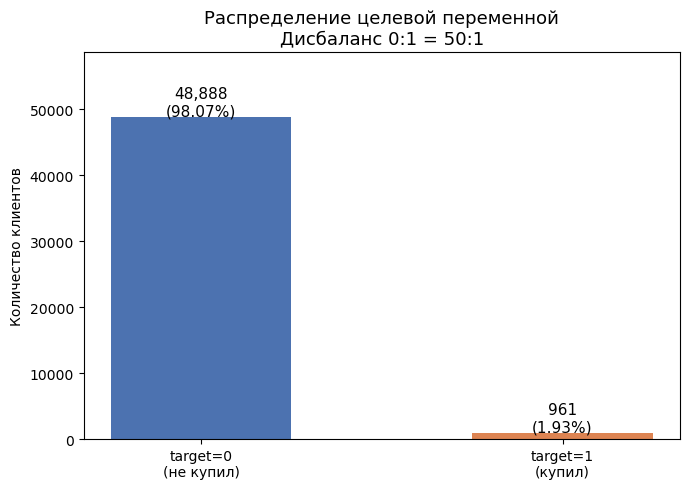

In [17]:
# =============================================================================
# Распределение целевой переменной
# =============================================================================

counts = target["target"].value_counts().sort_index()
pcts   = counts / len(target) * 100

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ["target=0\n(не купил)", "target=1\n(купил)"],
    counts.values,
    color=["#4C72B0", "#DD8452"],
    width=0.5
)

for bar, val, pct in zip(bars, counts.values, pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{val:,}\n({pct:.2f}%)",
        ha="center", fontsize=11
    )

ax.set_title(
    f"Распределение целевой переменной\n"
    f"Дисбаланс 0:1 = {int(counts[0]/counts[1])}:1",
    fontsize=13
)
ax.set_ylabel("Количество клиентов")
ax.set_ylim(0, counts.max() * 1.2)

plt.tight_layout()
plt.show()

### 3.2 Target rate по группам клиентов

=== Target rate по группам ===

  Группа                             Клиентов  Позитивов     Rate
  -----------------------------------------------------------------
  Все клиенты                          49,849        961    1.93%
  Есть messages                        41,982        846    2.02%
  Нет messages                          7,867        115    1.46%
  Нет покупок до CUTOFF                    79         10   12.66%
  Нет покупок + есть messages              68         10   14.71%
  Нет покупок + нет messages               11          0    0.00%


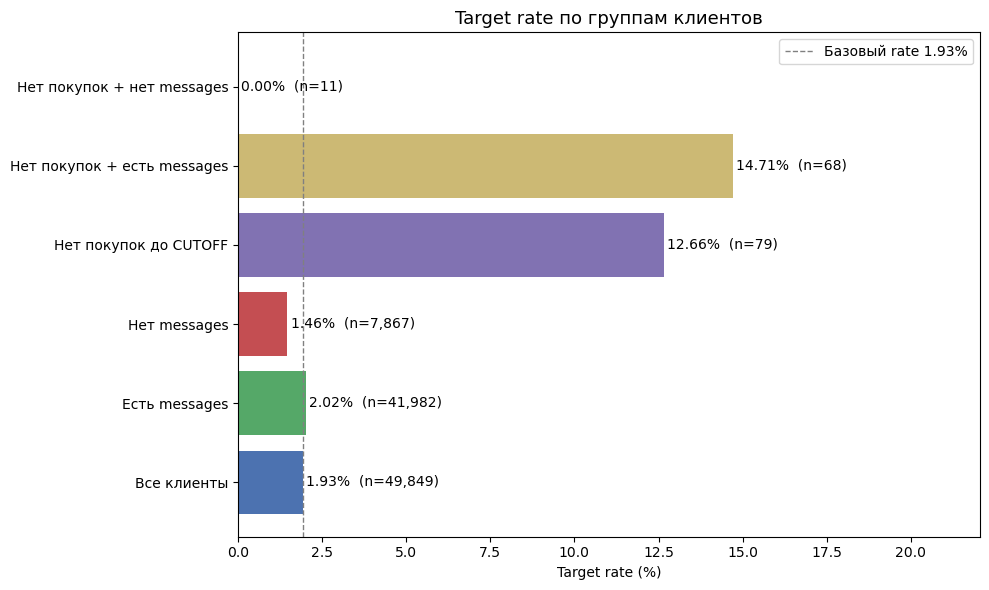

In [18]:
# =============================================================================
# Target rate по группам клиентов
# =============================================================================

# ── Группы ───────────────────────────────────────────────────────────────────
target_with_flags = target.copy()
target_with_flags["has_messages"] = (
    target["client_id"].astype(str).isin(msg_client_ids).astype(int)
)
target_with_flags["no_purchases"] = (
    (~target["client_id"].astype(str).isin(
        purch_raw[purch_raw["date"] < CUTOFF]["client_id"].astype(str)
    )).astype(int)
)

groups = {
    "Все клиенты":target_with_flags,
    "Есть messages":target_with_flags[target_with_flags["has_messages"] == 1],
    "Нет messages":target_with_flags[target_with_flags["has_messages"] == 0],
    "Нет покупок до CUTOFF":target_with_flags[target_with_flags["no_purchases"] == 1],
    "Нет покупок + есть messages": target_with_flags[(target_with_flags["no_purchases"] == 1) &(target_with_flags["has_messages"] == 1)],
    "Нет покупок + нет messages":target_with_flags[(target_with_flags["no_purchases"] == 1) &(target_with_flags["has_messages"] == 0)],
}

# ── Таблица ───────────────────────────────────────────────────────────────────
print("=== Target rate по группам ===\n")
print(f"  {'Группа':<32} {'Клиентов':>10} {'Позитивов':>10} {'Rate':>8}")
print("  " + "-" * 65)

rates, labels, sizes = [], [], []
for name, df in groups.items():
    n    = len(df)
    pos  = int(df["target"].sum())
    rate = pos / n * 100
    rates.append(rate)
    labels.append(name)
    sizes.append(n)
    print(f"  {name:<32} {n:>10,} {pos:>10,} {rate:>7.2f}%")

# ── Визуализация ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#4C72B0", "#55A868", "#C44E52",
          "#8172B2", "#CCB974", "#64B5CD"]

bars = ax.barh(labels, rates, color=colors)

for bar, rate, size in zip(bars, rates, sizes):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.2f}%  (n={size:,})",
        va="center", fontsize=10
    )

ax.axvline(rates[0], color="gray", linestyle="--",
           linewidth=1, label=f"Базовый rate {rates[0]:.2f}%")
ax.set_xlabel("Target rate (%)")
ax.set_title("Target rate по группам клиентов", fontsize=13)
ax.set_xlim(0, max(rates) * 1.5)
ax.legend()

plt.tight_layout()
plt.show()

#### Вывод
**Target rate по группам:**

| Группа | n | Rate |
|---|---:|---:|
| Все клиенты | 49,849 | 1.93% |
| Есть messages | 41,982 | 2.02% |
| Нет messages | 7,867 | 1.46% |
| Нет покупок до CUTOFF | 79 | 12.66% |
| Нет покупок + есть messages | 68 | 14.71% |
| Нет покупок + нет messages | 11 | 0.00% |



- В данных наблюдается сильный дисбаланс целевой переменной: положительный класс встречается редко, поэтому accuracy не подходит как основная метрика. Для оценки качества модели более уместны ROC-AUC и, дополнительно, precision/recall.
- Клиенты с рассылками имеют немного более высокий target rate, чем клиенты без рассылок: 2.02% против 1.46%. Сам факт наличия рассылки выглядит слабым, но потенциально полезным признаком.
- Наиболее высокий target rate наблюдается у клиентов без покупок до `CUTOFF`, но с рассылками: 14.71%. Однако размер этой группы небольшой — 68 клиентов, поэтому вывод следует интерпретировать осторожно.
- Высокий rate в группе клиентов без покупок до `CUTOFF` может указывать на сегмент новых или ранее неактивных клиентов, для которых маркетинговые коммуникации связаны с повышенной вероятностью покупки в целевом периоде.
- Для модели важно использовать не только бинарный признак `has_messages`, но и более детальные признаки поведения клиента: количество сообщений, каналы, типы событий, открытия, клики, частоту коммуникаций и давность последнего взаимодействия.

### 3.3 Target rate по каналу рассылки

=== Target rate по каналу рассылки ===

  Группа                 Клиентов  Позитивов     Rate
  ----------------------------------------------------
  Нет рассылок              7,868        115    1.46%
  Только email             11,623        171    1.47%
  Только push              10,096        246    2.44%
  Email + push             20,262        429    2.12%


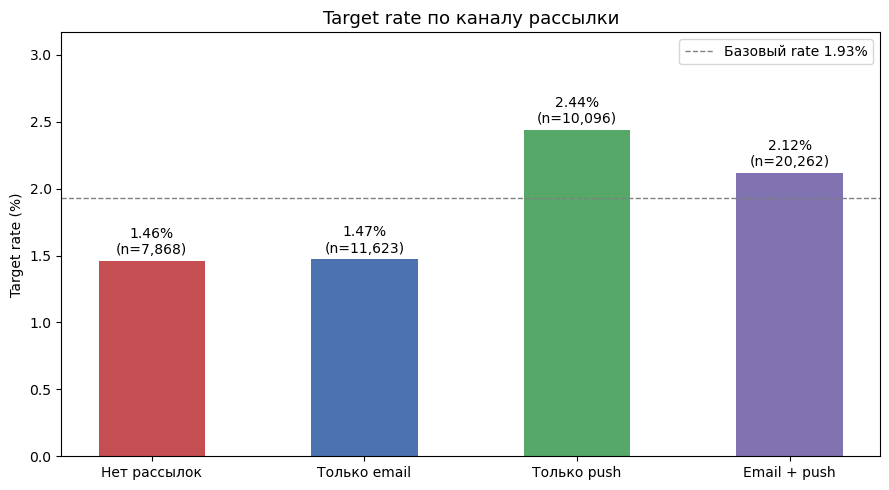

In [19]:
# =============================================================================
# Target rate по каналу рассылки
# =============================================================================

# ── Определяем каналы для каждого клиента через DuckDB ───────────────────────
channel_df = con.execute("""
    SELECT
        CAST(client_id AS VARCHAR)          AS client_id,
        MAX(CASE WHEN channel = 'email'        AND event = 'send' THEN 1 ELSE 0 END) AS has_email,
        MAX(CASE WHEN channel = 'mobile_push'  AND event = 'send' THEN 1 ELSE 0 END) AS has_push
    FROM messages
    GROUP BY client_id
""").df()

# ── Присоединяем к target ─────────────────────────────────────────────────────
target_ch = target.copy()
target_ch["client_id"] = target_ch["client_id"].astype(str)
target_ch = target_ch.merge(channel_df, on="client_id", how="left")
target_ch["has_email"] = target_ch["has_email"].fillna(0).astype(int)
target_ch["has_push"]  = target_ch["has_push"].fillna(0).astype(int)

# ── Группы по каналу ──────────────────────────────────────────────────────────
def channel_group(row):
    if row["has_email"] == 0 and row["has_push"] == 0:
        return "Нет рассылок"
    elif row["has_email"] == 1 and row["has_push"] == 0:
        return "Только email"
    elif row["has_email"] == 0 and row["has_push"] == 1:
        return "Только push"
    else:
        return "Email + push"

target_ch["channel_group"] = target_ch.apply(channel_group, axis=1)

# ── Таблица ───────────────────────────────────────────────────────────────────
print("=== Target rate по каналу рассылки ===\n")
print(f"  {'Группа':<20} {'Клиентов':>10} {'Позитивов':>10} {'Rate':>8}")
print("  " + "-" * 52)

order  = ["Нет рассылок", "Только email", "Только push", "Email + push"]
rates, labels, sizes = [], [], []

for grp in order:
    df   = target_ch[target_ch["channel_group"] == grp]
    n    = len(df)
    pos  = int(df["target"].sum())
    rate = pos / n * 100 if n > 0 else 0
    rates.append(rate)
    labels.append(grp)
    sizes.append(n)
    print(f"  {grp:<20} {n:>10,} {pos:>10,} {rate:>7.2f}%")

# ── Визуализация ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

colors = ["#C44E52", "#4C72B0", "#55A868", "#8172B2"]
bars   = ax.bar(labels, rates, color=colors, width=0.5)

for bar, rate, size in zip(bars, rates, sizes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{rate:.2f}%\n(n={size:,})",
        ha="center", fontsize=10
    )

ax.axhline(1.93, color="gray", linestyle="--",
           linewidth=1, label="Базовый rate 1.93%")
ax.set_ylabel("Target rate (%)")
ax.set_title("Target rate по каналу рассылки", fontsize=13)
ax.set_ylim(0, max(rates) * 1.3)
ax.legend()

plt.tight_layout()
plt.show()

**Выводы:**

- Push-канал эффективнее email: только push даёт 2.44%
  против 1.47% у только email — разница в 1.66×.
- Email-рассылки практически не влияют на конверсию (1.47% ≈ 1.46%
  у клиентов без рассылок вообще).
- Группа "Email + push" — клиенты получавшие разные кампании по разным каналам
  (каждая кампания строго одноканальна). Их rate 2.12% ниже
  только push (2.44%)
- Клиенты с преобладанием push-кампаний конвертируются лучше.
  Признак `push_share` (доля push-кампаний в общем миксе клиента)
  потенциально информативен для модели.

### 3.4 Исследование покупок

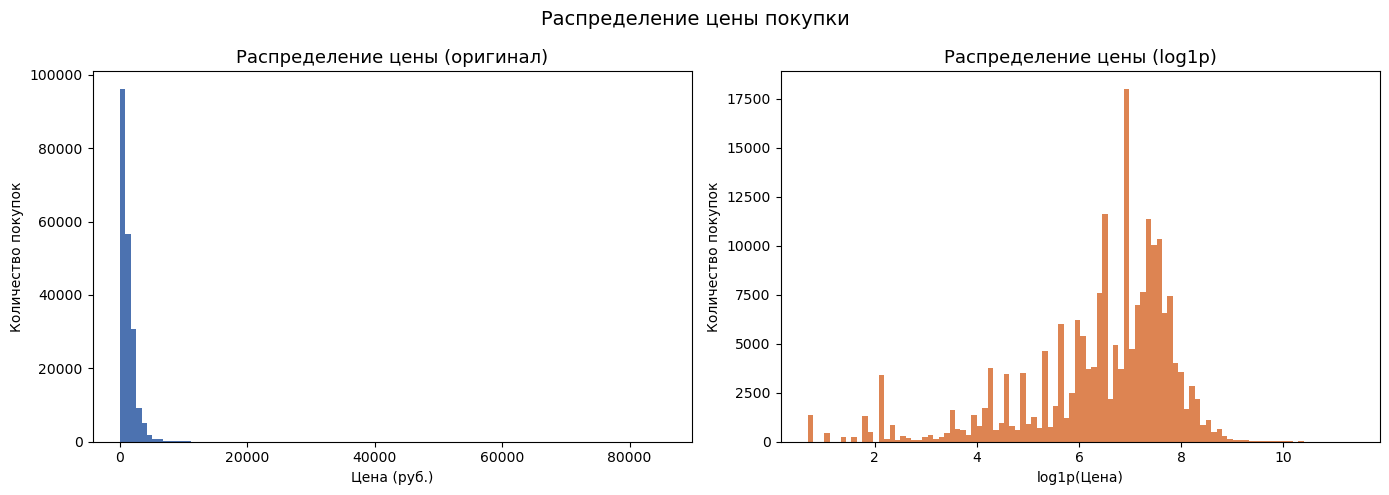

=== Статистика цены ===

count    201,692.0
mean       1,194.0
std        1,343.0
min            1.0
25%          352.0
50%          992.0
75%        1,699.0
max       85,499.0

  Skewness:  8.58
  Kurtosis:  246.98


In [20]:
# =============================================================================
#Распределение цены покупки
# =============================================================================
purch_before = purch_raw[purch_raw["date"] < CUTOFF].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Левый: оригинальная шкала ─────────────────────────────────────────────────
axes[0].hist(purch_before["price"], bins=100, color="#4C72B0", edgecolor="none")
axes[0].set_title("Распределение цены (оригинал)", fontsize=13)
axes[0].set_xlabel("Цена (руб.)")
axes[0].set_ylabel("Количество покупок")

# ── Правый: log1p шкала ───────────────────────────────────────────────────────
axes[1].hist(np.log1p(purch_before["price"]), bins=100,
             color="#DD8452", edgecolor="none")
axes[1].set_title("Распределение цены (log1p)", fontsize=13)
axes[1].set_xlabel("log1p(Цена)")
axes[1].set_ylabel("Количество покупок")

plt.suptitle("Распределение цены покупки", fontsize=14)
plt.tight_layout()
plt.show()

# ── Статистика ────────────────────────────────────────────────────────────────
print("=== Статистика цены ===\n")
print(purch_before["price"].describe().apply(lambda x: f"{x:,.1f}").to_string())
print(f"\n  Skewness:  {purch_before['price'].skew():.2f}")
print(f"  Kurtosis:  {purch_before['price'].kurt():.2f}")

**Распределение цены:**

- Выраженная правая скошенность: skewness=8.58, kurtosis=246.98.
  Медиана 992 руб., среднее 1,194 руб., максимум 85,499 руб.
- log1p не нормализует распределение — выявляет мультимодальность:
  товары сгруппированы в ценовые кластеры.
- Для линейных моделей применяем log1p к признакам `monetary_total`,
  `avg_check`, `price_q25`, `price_q75`, `max_price`.
  Для LightGBM трансформация не требуется.

=== Статистика n_orders ===

count    49,770.0
mean          1.2
std           0.7
min           1.0
25%           1.0
50%           1.0
75%           1.0
max          41.0

  Skewness:  9.96
  Клиентов с 1 заказом:   42,645  (85.7%)
  Клиентов с 2+ заказами:  7,125  (14.3%)


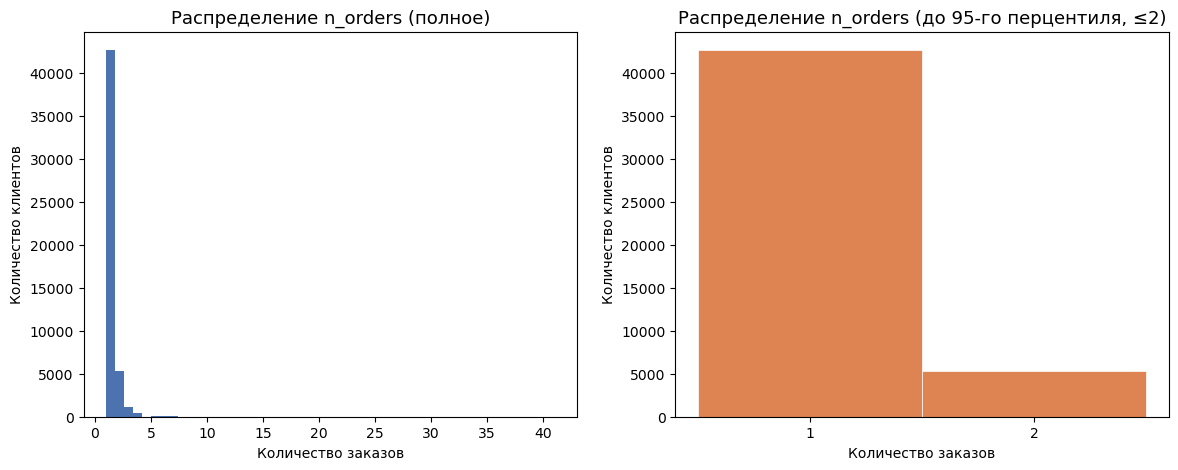

In [21]:
# =============================================================================
# Распределение количества заказов на клиента
# =============================================================================

orders_per_client = (
    purch_before
    .groupby("client_id")["date"]
    .nunique()
    .rename("n_orders")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Левый: полное распределение ───────────────────────────────────────────────
axes[0].hist(orders_per_client["n_orders"], bins=50,
             color="#4C72B0", edgecolor="none")
axes[0].set_title("Распределение n_orders (полное)", fontsize=13)
axes[0].set_xlabel("Количество заказов")
axes[0].set_ylabel("Количество клиентов")

# ── Правый: без выбросов (до 95 перцентиля) ──────────────────────────────────
p95 = int(orders_per_client["n_orders"].quantile(0.95))
data_trimmed = orders_per_client[orders_per_client["n_orders"] <= p95]["n_orders"]

axes[1].hist(
    data_trimmed,
    bins=range(1, p95 + 2),  # целые бины: 1, 2, 3, ... p95
    color="#DD8452",
    edgecolor="white",
    linewidth=0.5,
    align="left"
)
axes[1].set_title(f"Распределение n_orders (до 95-го перцентиля, ≤{p95})",
                  fontsize=13)
axes[1].set_xlabel("Количество заказов")
axes[1].set_ylabel("Количество клиентов")
axes[1].set_xticks(range(1, p95 + 1))

# ── Статистика ────────────────────────────────────────────────────────────────
print("=== Статистика n_orders ===\n")
print(orders_per_client["n_orders"].describe().apply(
    lambda x: f"{x:,.1f}").to_string())
print(f"\n  Skewness:  {orders_per_client['n_orders'].skew():.2f}")
print(f"  Клиентов с 1 заказом:   "
      f"{(orders_per_client['n_orders'] == 1).sum():>6,}  "
      f"({(orders_per_client['n_orders'] == 1).mean()*100:.1f}%)")
print(f"  Клиентов с 2+ заказами: "
      f"{(orders_per_client['n_orders'] >= 2).sum():>6,}  "
      f"({(orders_per_client['n_orders'] >= 2).mean()*100:.1f}%)")

**Количество заказов на клиента:**

- Распределение `n_orders` сильно скошено вправо: 85.7% клиентов сделали ровно 1 заказ, медиана и 75-й перцентиль равны 1. Это означает, что для большинства клиентов интервалы между заказами не определены.
- добавим бинарный признак `is_single_order`, а интервальные признаки `days_between_orders_avg` и `days_between_orders_median` будем считать только для клиентов с 2+ заказами.
- Признак `n_orders` потенциально важен для модели, так как выделяет повторных покупателей.

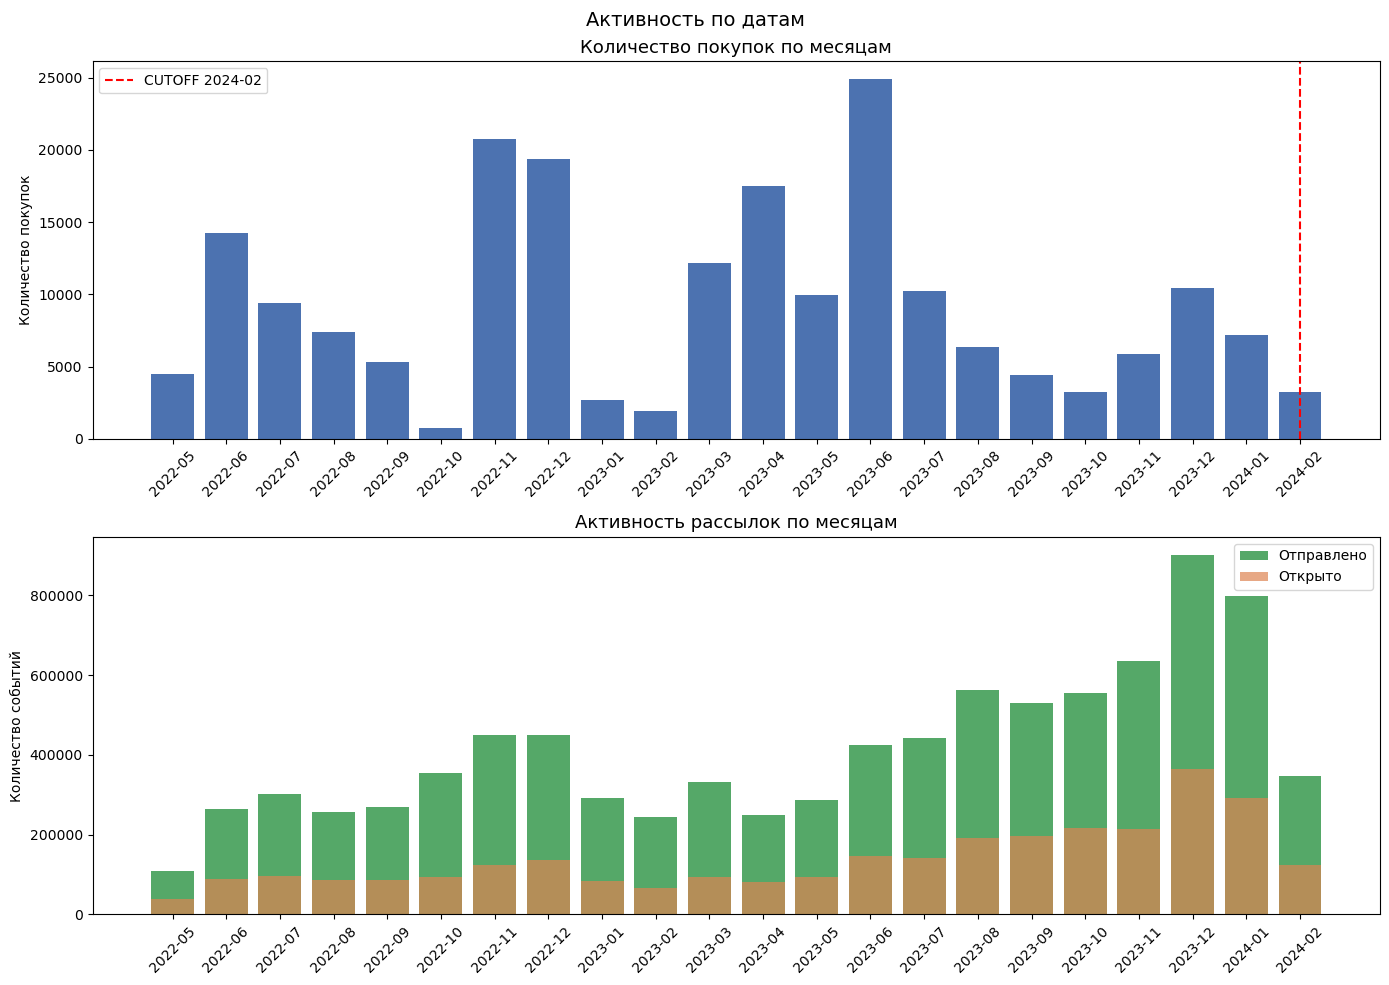

In [22]:
# =============================================================================
#  Активность по датам
# =============================================================================

# ── Покупки по месяцам ────────────────────────────────────────────────────────
purch_by_month = (
    purch_before
    .assign(month=purch_before["date"].dt.to_period("M"))
    .groupby("month")
    .agg(n_orders=("date", "count"),
         n_clients=("client_id", "nunique"))
    .reset_index()
)
purch_by_month["month_str"] = purch_by_month["month"].astype(str)

# ── Рассылки по месяцам (через DuckDB) ───────────────────────────────────────
msg_by_month = con.execute("""
    SELECT
        strftime(date, '%Y-%m')                         AS month_str,
        COUNT(*)                                        AS n_events,
        COUNT(DISTINCT client_id)                       AS n_clients,
        SUM(CASE WHEN event='send' THEN 1 ELSE 0 END)  AS n_send,
        SUM(CASE WHEN event='open' THEN 1 ELSE 0 END)  AS n_open
    FROM messages
    GROUP BY month_str
    ORDER BY month_str
""").df()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Верхний: покупки по месяцам ───────────────────────────────────────────────
axes[0].bar(purch_by_month["month_str"], purch_by_month["n_orders"],
            color="#4C72B0", edgecolor="none")
axes[0].set_title("Количество покупок по месяцам", fontsize=13)
axes[0].set_ylabel("Количество покупок")
axes[0].tick_params(axis="x", rotation=45)
axes[0].axvline(
    purch_by_month[purch_by_month["month_str"] == "2024-02"].index[0],
    color="red", linestyle="--", linewidth=1.5, label="CUTOFF 2024-02"
)
axes[0].legend()

# ── Нижний: рассылки по месяцам ───────────────────────────────────────────────
axes[1].bar(msg_by_month["month_str"], msg_by_month["n_send"],
            color="#55A868", edgecolor="none", label="Отправлено")
axes[1].bar(msg_by_month["month_str"], msg_by_month["n_open"],
            color="#DD8452", edgecolor="none", label="Открыто", alpha=0.7)
axes[1].set_title("Активность рассылок по месяцам", fontsize=13)
axes[1].set_ylabel("Количество событий")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.suptitle("Активность по датам", fontsize=14)
plt.tight_layout()
plt.show()

**Выводы:**

- Покупательская активность распределена неравномерно по месяцам. На графике видны выраженные пики в ноябре–декабре 2022 года, июне 2023 года и декабре 2023 года. Это может быть связано с сезонностью, распродажами или маркетинговыми активностями.
- Октябрь 2022 года выглядит аномально низким по количеству покупок. Это может быть связано с неполным периодом наблюдений, техническими особенностями сбора данных или реальным снижением активности. Требуется дополнительная проверка календарного покрытия данных.
- Объём событий рассылок заметно увеличивается к концу периода: максимальная активность наблюдается в декабре 2023 — январе 2024 года.
- На графике рассылок показаны абсолютные количества отправленных и открытых сообщений. Для оценки эффективности коммуникаций необходимо дополнительно рассчитать относительные метрики, например долю открытий от отправленных сообщений.
- `CUTOFF` приходится на февраль 2024 года, поэтому последний месяц является неполным. Сравнивать февраль напрямую с полными месяцами некорректно.

### 3.6 Распределение событий в рассылках

=== Распределение событий ===

  Event                Событий       %     Клиентов       %
  ----------------------------------------------------------
  send               9,058,174  71.37%       53,303  25.86%
  open               3,052,481  24.05%       44,710  21.69%
  click                483,326   3.81%       48,060  23.31%
  purchase              62,593   0.49%       42,055  20.40%
  hard_bounce           19,763   0.16%       12,752   6.19%
  soft_bounce           10,582   0.08%        1,882   0.91%
  unsubscribe            2,833   0.02%        2,209   1.07%
  hbq_spam                 823   0.01%          806   0.39%
  complain                 527   0.00%          281   0.14%
  subscribe                 85   0.00%           75   0.04%
  close                      1   0.00%            1   0.00%


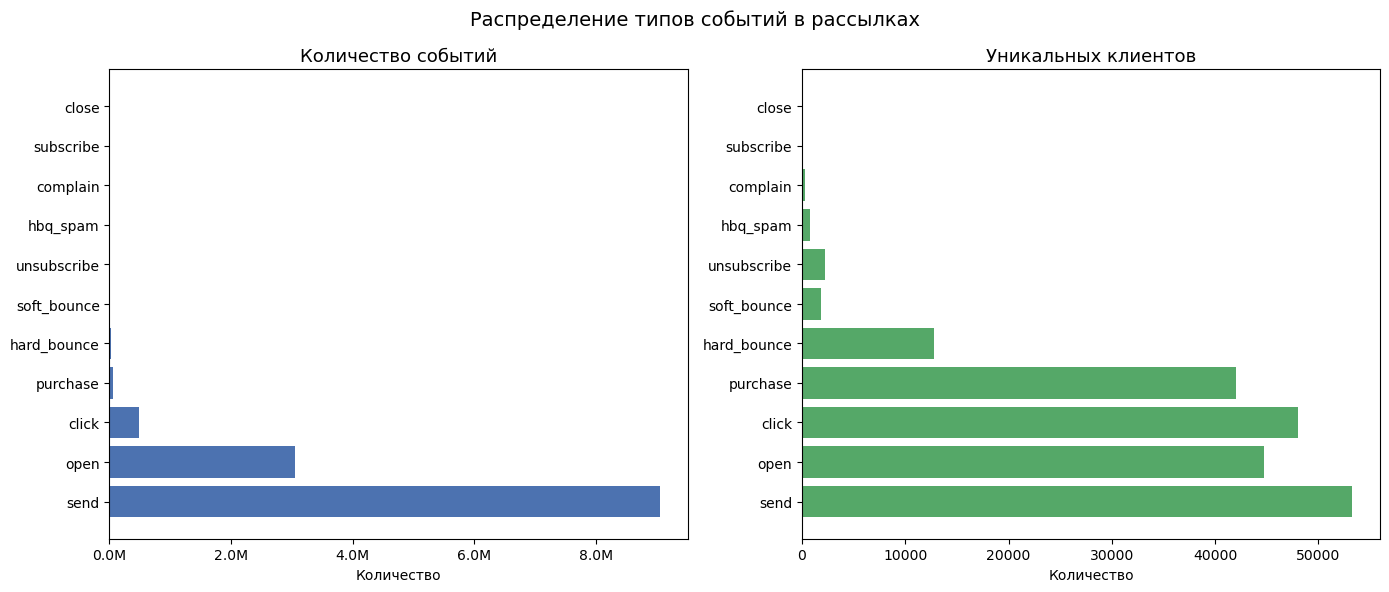

In [23]:
# =============================================================================
# Распределение событий в рассылках
# =============================================================================

event_stats = con.execute("""
    SELECT
        event,
        COUNT(*)                    AS n_events,
        COUNT(DISTINCT client_id)   AS n_clients
    FROM messages
    GROUP BY event
    ORDER BY n_events DESC
""").df()

event_stats["pct_events"]  = event_stats["n_events"]  / event_stats["n_events"].sum()  * 100
event_stats["pct_clients"] = event_stats["n_clients"] / event_stats["n_clients"].sum() * 100

print("=== Распределение событий ===\n")
print(f"  {'Event':<15} {'Событий':>12} {'%':>7} {'Клиентов':>12} {'%':>7}")
print("  " + "-" * 58)
for _, row in event_stats.iterrows():
    print(f"  {row['event']:<15} {int(row['n_events']):>12,} "
          f"{row['pct_events']:>6.2f}% "
          f"{int(row['n_clients']):>12,} "
          f"{row['pct_clients']:>6.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Левый: количество событий ─────────────────────────────────────────────────
axes[0].barh(event_stats["event"], event_stats["n_events"],
             color="#4C72B0", edgecolor="none")
axes[0].set_title("Количество событий", fontsize=13)
axes[0].set_xlabel("Количество")
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
)

# ── Правый: количество уникальных клиентов ────────────────────────────────────
axes[1].barh(event_stats["event"], event_stats["n_clients"],
             color="#55A868", edgecolor="none")
axes[1].set_title("Уникальных клиентов", fontsize=13)
axes[1].set_xlabel("Количество")

plt.suptitle("Распределение типов событий в рассылках", fontsize=14)
plt.tight_layout()
plt.show()

**Воронка событий:**

| Event | Событий | % | Клиентов |
|---|---|---|---|
| send | 9,058,174 | 71.37% | 53,303 |
| open | 3,052,481 | 24.05% | 44,710 |
| click | 483,326 | 3.81% | 48,060 |
| purchase | 62,593 | 0.49% | 42,055 |

**Выводы:**

- Базовый open rate ~33.7%, click rate ~5.3% по всей выборке.
- Клиентов с click больше чем с open (48,060 vs 44,710) —
  следствие асинхронного лога
- `unsubscribe` (2,209 клиентов) и `complain` (281 клиент) —
  используем как бинарные флаги `has_unsubscribe`, `has_complain`.
- `hard_bounce` (12,752 клиентов) — недоставленные сообщения,
  потенциально информативный признак негативной вовлечённости.
- `close` (1 событие) — игнорируем.
- `purchase` из messages исключаем — дублирует `apparel-purchases.csv`.

<a id="sec4"></a>
## 4. Инжиниринг признаков

### 4.1 RFM-признаки и ценовые характеристики (Group 1)

RFM-признаки (`Recency`, `Frequency`, `Monetary`) — классический набор признаков для задач маркетинговой аналитики и прогнозирования клиентского поведения. Они описывают давность, частоту и денежную ценность покупок клиента до точки отсечения `CUTOFF = 2024-02-16`.

На основе `apparel-purchases.csv` строятся два промежуточных датафрейма, которые далее войдут в финальную матрицу признаков.

`rfm` — признаки покупательской активности:

- `recency_purchase` — количество дней от последней покупки до `CUTOFF`: чем меньше значение, тем более недавно клиент покупал;
- `monetary_total` — суммарная выручка по клиенту;
- `avg_check` — средний чек одного заказа;
- `avg_items_per_order` — среднее количество товаров в заказе;
- `n_orders` — количество заказов;
- `purch_lifetime_days` — количество дней между первой и последней покупкой;
- `days_between_orders_avg` — средний интервал между заказами;
- `days_between_orders_median` — медианный интервал между заказами.

`price_feats` — признаки ценового сегмента клиента:

- `price_q25` — 25-й перцентиль цены товаров, которые покупал клиент;
- `price_q75` — 75-й перцентиль цены товаров, которые покупал клиент;
- `max_price` — максимальная цена товара в истории покупок клиента.

**Методологические решения:**

- В данных нет явного идентификатора заказа, поэтому заказ определяется как уникальная пара `(client_id, date)`. Это допущение: если клиент сделал несколько независимых заказов в один день, они будут объединены в один заказ. Однако при отсутствии `order_id` такой подход позволяет отделить товарные строки одного дня от разных дней покупок.
- Признак `Frequency` эквивалентен количеству заказов `n_orders`, поэтому в финальной матрице признаков оставляется только `n_orders`, чтобы не дублировать одинаковую информацию.

**Структурные пропуски:**

- 79 клиентов не имеют покупок до `CUTOFF`. Для них RFM- и ценовые признаки не могут быть рассчитаны, поскольку в историческом окне нет покупательской информации. Все их RFM и ценовые признаки будут NaN — структурный пропуск несущий информацию.
`days_between_orders_avg/median` будут NaN у 85.7% клиентов (единственный заказ → интервал не определён) — это тоже структурный
пропуск.
- Для моделей, которые не поддерживают пропуски нативно, обработка NaN выполняется внутри `Pipeline` с помощью `SimpleImputer`. Дополнительно можно добавить бинарные индикаторы отсутствия покупок до `CUTOFF` и единственного заказа.

In [24]:
# =============================================================================
# RFM-признаки и ценовые характеристики
# =============================================================================

# ── Заказы: агрегируем позиции в заказы на уровне (client_id, date) ───────────
# Одна дата = один заказ, несколько строк = позиции этого заказа
purch_before["line_total"] = purch_before["price"] * purch_before["quantity"]

orders = (
    purch_before
    .groupby(["client_id", "date"])
    .agg(
        order_total=("line_total", "sum"),
        order_items=("quantity",   "sum")
    )
    .reset_index()
)

# ── RFM-признаки ──────────────────────────────────────────────────────────────
rfm = (
    orders
    .groupby("client_id")
    .agg(
        recency_purchase    =("date",        lambda x: (CUTOFF - x.max()).days),
        monetary_total      =("order_total", "sum"),
        avg_check           =("order_total", "mean"),
        avg_items_per_order =("order_items", "mean"),
        n_orders            =("date",        "count"),
        purch_lifetime_days =("date",        lambda x: (x.max() - x.min()).days),
    )
    .reset_index()
)

# ── Среднее и медианное время между заказами ──────────────────────────────────
# NaN у клиентов с единственным заказом (85.7%) — структурный пропуск,
# несёт информацию: клиент никогда не возвращался
def interorder_stats(dates: pd.Series) -> pd.Series:
    """Среднее и медианное время между заказами в днях.

    Возвращает NaN если у клиента менее 2 заказов.
    """
    d = sorted(dates.unique())
    if len(d) < 2:
        return pd.Series({
            "days_between_orders_avg":    np.nan,
            "days_between_orders_median": np.nan
        })
    diffs = [(d[i+1] - d[i]).days for i in range(len(d) - 1)]
    return pd.Series({
        "days_between_orders_avg":    float(np.mean(diffs)),
        "days_between_orders_median": float(np.median(diffs))
    })

interorder = (
    orders
    .groupby("client_id")["date"]
    .apply(interorder_stats)
    .unstack()
    .reset_index()
)

rfm = rfm.merge(interorder, on="client_id", how="left")

# ── Ценовые признаки ──────────────────────────────────────────────────────────
# Квартили и максимум цены — профиль ценового сегмента клиента
price_feats = (
    purch_before
    .groupby("client_id")["price"]
    .agg(
        price_q25=lambda x: x.quantile(0.25),
        price_q75=lambda x: x.quantile(0.75),
        max_price="max"
    )
    .reset_index()
)

# ── Валидация ─────────────────────────────────────────────────────────────────
print("=== RFM + Price ===\n")
print(f"  Клиентов в rfm:         {len(rfm):>8,}  (ожидается 49,770)")
print(f"  Признаков в rfm:        {len(rfm.columns)-1:>8}")
print(f"  Клиентов в price_feats: {len(price_feats):>8,}")
print(f"\n  NaN в days_between_orders_avg: "
      f"{rfm['days_between_orders_avg'].isna().sum():>6,}  "
      f"({rfm['days_between_orders_avg'].isna().mean()*100:.1f}%)")
print(f"\n  Пример rfm:")
print(
    rfm.head(3)
    .set_index("client_id")
    .T
    .to_string(float_format="{:.2f}".format)
)

=== RFM + Price ===

  Клиентов в rfm:           49,770  (ожидается 49,770)
  Признаков в rfm:               8
  Клиентов в price_feats:   49,770

  NaN в days_between_orders_avg: 42,645  (85.7%)

  Пример rfm:
client_id                   1515915625468060902  1515915625468061003  1515915625468061099
recency_purchase                         630.00               408.00               640.00
monetary_total                          6993.00             16235.00               299.00
avg_check                               6993.00             16235.00               299.00
avg_items_per_order                        7.00                 7.00                 1.00
n_orders                                   1.00                 1.00                 1.00
purch_lifetime_days                        0.00                 0.00                 0.00
days_between_orders_avg                     NaN                  NaN                  NaN
days_between_orders_median                  NaN                  NaN 

### 4.2 Категории товаров (Group 2)

Каждая товарная строка в `apparel-purchases.csv` содержит колонку `category_ids` — список идентификаторов категорий товара, записанный в виде строки, например `['4', '28', '57', '431']`.

Структура списка не гарантированно стабильна —
первый элемент условно рассматривается как верхнеуровневая категория,
однако он может содержать маркер распродажи, гендерный маркер
или другой служебный тег. Дерево категорий также могло обновляться
за период наблюдения (2022–2024)

**Что вычисляем:**

`cat_feats` — признаки товарных категорий клиента:

- `n_unique_categories` — количество уникальных категорий, встречавшихся в покупках клиента;
- `has_root_4`, `has_root_5562`, `has_root_2`, `has_root_6060`, `has_root_5963` — бинарные флаги покупок в топ-5 условных верхнеуровневых категориях (покрывают ~97% покупок);
- `cat_main_leaf_share` — доля товарных строк клиента, относящихся к самой частой детальной категории.

**Методологические решения:**

- Категории используются как поведенческие признаки товарных предпочтений клиента.
- Детальные категории не используются как отдельные признаки в полном виде, так как их много, а значительная часть встречается редко. Это привело бы к высокой разреженности признакового пространства.
- Для снижения размерности используются только топ-5 условных верхнеуровневых категорий, которые покрывают большую часть покупок.
- Пустые значения `category_ids` обрабатываются отдельно: для таких строк нет подтверждённой информации о принадлежности товара к категориям. Поэтому бинарные флаги популярных категорий заполняются нулями, а количество уникальных категорий — значением 0.

In [25]:
# =============================================================================
# Категории товаров
# =============================================================================
# ── category_ids → список категорий ───────────────────────────────────
purch_before["cats"] = purch_before["category_ids"].apply(
    lambda s: ast.literal_eval(s) if isinstance(s, str) and s.startswith("[") else []
)

# Условно первый элемент = верхнеуровневая категория
# Последний элемент = листовая категория
purch_before["root_cat"] = purch_before["cats"].apply(
    lambda x: x[0] if x else None
)
purch_before["leaf_cat"] = purch_before["cats"].apply(
    lambda x: x[-1] if x else None
)

# ── Топ-5 верхнеуровневых категорий (~97% покупок) ───────────────────────────
ROOT_CATS = ["4", "5562", "2", "6060", "5963"]

# ── n_unique_categories ───────────────────────────────────────────────────────
# explode разворачивает список категорий в отдельные строки
purch_exp = purch_before.explode("cats")
cat_feats = (
    purch_exp
    .groupby("client_id")["cats"]
    .nunique()
    .rename("n_unique_categories")
    .reset_index()
)

# ── Бинарные флаги верхнеуровневых категорий ─────────────────────────────────
for root in ROOT_CATS:
    clients_with_root = (
        purch_before[purch_before["root_cat"] == root]
        ["client_id"]
        .unique()
    )
    cat_feats[f"has_root_{root}"] = (
        cat_feats["client_id"]
        .isin(clients_with_root)
        .astype(int)
    )

# ── cat_main_leaf_share ───────────────────────────────────────────────────────
# Доля покупок в самой популярной листовой категории клиента
# Показывает насколько клиент сконцентрирован в одной нише
leaf_cnt = (
    purch_before
    .groupby(["client_id", "leaf_cat"])
    .size()
    .reset_index(name="cnt")
)
max_leaf  = leaf_cnt.groupby("client_id")["cnt"].max()
tot_lines = purch_before.groupby("client_id").size()

cat_feats = cat_feats.merge(
    (max_leaf / tot_lines.replace(0, np.nan))
    .rename("cat_main_leaf_share")
    .fillna(0)
    .reset_index(),
    on="client_id", how="left"
)

# ── Валидация ─────────────────────────────────────────────────────────────────
print("=== Категории товаров ===\n")
print(f"  Клиентов в cat_feats:   {len(cat_feats):>8,}  (ожидается 49,770)")
print(f"  Признаков:              {len(cat_feats.columns)-1:>8}")
print(f"  NaN в cat_feats:        {cat_feats.isnull().sum().sum():>8,}")

print(f"\n  Покрытие топ-5 категорий:")
for root in ROOT_CATS:
    col = f"has_root_{root}"
    n   = cat_feats[col].sum()
    pct = n / len(cat_feats) * 100
    print(f"    has_root_{root:<6}: {n:>6,} клиентов ({pct:.1f}%)")



print(f"\n  Пример cat_feats:")
print(
    cat_feats.head(4)
    .set_index("client_id")
    .T
    .to_string(float_format="{:.2f}".format)
)

# ── Очистка промежуточных объектов ───────────────────────────────────────────
del purch_exp, leaf_cnt, max_leaf, tot_lines


=== Категории товаров ===

  Клиентов в cat_feats:     49,770  (ожидается 49,770)
  Признаков:                     7
  NaN в cat_feats:               0

  Покрытие топ-5 категорий:
    has_root_4     : 33,541 клиентов (67.4%)
    has_root_5562  : 11,890 клиентов (23.9%)
    has_root_2     : 10,069 клиентов (20.2%)
    has_root_6060  :  1,725 клиентов (3.5%)
    has_root_5963  :    548 клиентов (1.1%)

  Пример cat_feats:
client_id            1515915625468060902  1515915625468061003  1515915625468061099  1515915625468061100
n_unique_categories                13.00                 4.00                 4.00                 4.00
has_root_4                          1.00                 1.00                 1.00                 1.00
has_root_5562                       0.00                 0.00                 0.00                 0.00
has_root_2                          0.00                 0.00                 0.00                 0.00
has_root_6060                       0.00               

### 4.3 Признаки вовлечённости (Group 3)

На основе `apparel-messages.csv` строятся признаки, описывающие поведение клиента в ответ на маркетинговые рассылки до точки отсечения `CUTOFF`.

Эти признаки отражают не только факт получения коммуникаций, но и реакцию клиента: открытия, клики, отписки, жалобы, активность по каналам и давность последнего взаимодействия.

**Что вычисляем:**

`msg_feats` — признаки вовлечённости клиента в маркетинговые коммуникации.

**Объём кампаний:**

- `n_campaigns_sent` — количество кампаний, в которых клиенту было отправлено сообщение;
- `n_campaigns_opened` — количество кампаний, в которых клиент открыл сообщение;
- `n_campaigns_clicked` — количество кампаний, в которых клиент кликнул по сообщению;
- `n_camps_any` — количество уникальных кампаний с любым зафиксированным событием клиента.

**Относительные показатели:**

- `open_rate` — доля открытых кампаний;
- `click_rate` — доля кампаний с кликом;
- `click_to_open_rate` — доля кампаний с кликом среди кампаний с открытием.

Если из-за особенностей логирования встречаются события `open` или `click` без события `send`, для расчёта долей используется устойчивый знаменатель `n_camps_any`. Такой подход снижает риск появления некорректных значений больше 1, но при интерпретации важно учитывать, что это не классический open rate от числа отправок, а доля открытий среди кампаний с любым событием.

**Каналы:**

- `n_send_email`, `n_send_push` — количество отправок по каналам;
- `push_share` — доля push-отправок среди всех отправок;
- `email_click_to_open_rate`, `push_click_to_open_rate` — отношение кликов к открытиям по каждому каналу.

**Временны́е признаки:**

- `recency_last_open` — количество дней от последнего открытия до `CUTOFF`;
- `recency_last_click` — количество дней от последнего клика до `CUTOFF`;
- `days_since_first_event` — количество дней от первого события клиента до `CUTOFF`;
- `active_days_span` — количество дней между первым и последним событием клиента;
- `msg_n_active_days` — количество уникальных дней, в которые у клиента были события рассылок.

**Поведенческие флаги и производные признаки:**

- `engagement_lift` — отношение фактического количества открытий к ожидаемому количеству открытий с учётом каналов коммуникации;
- `purchase_to_click_rate` — доля кампаний с кликом, которые связаны с покупкой;
- `has_messages` — бинарный флаг наличия рассылок у клиента;
- `has_unsubscribe` — бинарный флаг наличия отписки;
- `has_complain` — бинарный флаг наличия жалобы.

Формула `engagement_lift`:

**engagement_lift** = ***n_opened / (n_send_email × P_email + n_send_push × P_push)*** , где P_email, P_push  — базовые open rate,
рассчитанные по историческим данным до CUTOFF.

**Методологические решения:**

- **Бинаризация:** open/click считаются на уровне
  `(client_id, bulk_campaign_id, channel)` — один пиксель
  может сработать многократно, учитывается только сам факт события.
- **Дубли в messages:** при чтении используется `SELECT DISTINCT`
  в DuckDB — дубли исключаются на уровне запроса.
- **`purchase_to_click_rate`:** числитель — уникальные кампании
  из `apparel-purchases.csv`, где покупка атрибутирована рассылке
  через `message_id`. Знаменатель — `n_campaigns_clicked`.
- **Клиенты без messages (7,867 клиентов, 15.8%):**
  - счётчики (`n_campaigns_sent` и др.) и флаги
    (`has_unsubscribe`, `has_complain`) → **0**
  - rates и recency-признаки → **NaN** (не определены)
  - `has_messages = 0` позволяет модели явно различать две группы.
- Для tree-based моделей NaN обрабатывается нативно;
  для LogReg — через `SimpleImputer` внутри Pipeline.

In [26]:
%%time
# =============================================================================
# Признаки вовлечённости (Engagement)
# =============================================================================

# ── Бинаризация событий на уровне (client_id, campaign, channel) ──────────────
# MAX() по группе даёт 1 если событие было хотя бы раз — факт, не счётчик
camp = con.execute("""
    SELECT
        CAST(client_id AS VARCHAR)        AS client_id,
        CAST(bulk_campaign_id AS VARCHAR) AS bulk_campaign_id,
        channel,
        MAX(CASE WHEN event='send'  THEN 1 ELSE 0 END) AS did_send,
        MAX(CASE WHEN event='open'  THEN 1 ELSE 0 END) AS did_open,
        MAX(CASE WHEN event='click' THEN 1 ELSE 0 END) AS did_click
    FROM messages
    GROUP BY client_id, bulk_campaign_id, channel
""").df()

# ── Базовые open rate по каналу на уровне (client, campaign) ─────────────────
# P = доля (client, campaign, channel) пар где был send И было open
# Это корректный уровень для engagement_lift: сравниваем поведение клиента
# со средним поведением пары (клиент, кампания) по каждому каналу
channel_base = (
    camp[camp["did_send"] == 1]
    .groupby("channel")[["did_send", "did_open"]]
    .sum()
    .reset_index()
)
channel_base["base_open_rate"] = (
    channel_base["did_open"] / channel_base["did_send"]
)

print("=== Базовые open rate по каналу (уровень campaign × client) ===\n")
print(channel_base.to_string(index=False, float_format="{:.3f}".format))

P_EMAIL = float(channel_base.loc[
    channel_base["channel"] == "email", "base_open_rate"].iloc[0])
P_PUSH  = float(channel_base.loc[
    channel_base["channel"] == "mobile_push", "base_open_rate"].iloc[0])

print(f"\n  P_email = {P_EMAIL:.3f}")
print(f"  P_push  = {P_PUSH:.3f}")

# ── Объём кампаний ────────────────────────────────────────────────────────────
vol = (
    camp
    .groupby("client_id")
    .agg(
        n_campaigns_sent    =("did_send",  "sum"),
        n_campaigns_opened  =("did_open",  "sum"),
        n_campaigns_clicked =("did_click", "sum"),
    )
    .reset_index()
)

n_any = (
    camp
    .groupby("client_id")["bulk_campaign_id"]
    .nunique()
    .rename("n_camps_any")
    .reset_index()
)

vol = vol.merge(n_any, on="client_id", how="left")

# ── Rates (знаменатель = n_camps_any) ─────────────────────────────────────────
vol["open_rate"]          = (
    vol["n_campaigns_opened"] /
    vol["n_camps_any"].replace(0, np.nan)
).clip(0, 1)
vol["click_rate"]         = (
    vol["n_campaigns_clicked"] /
    vol["n_camps_any"].replace(0, np.nan)
).clip(0, 1)
vol["click_to_open_rate"] = (
    vol["n_campaigns_clicked"] /
    vol["n_campaigns_opened"].replace(0, np.nan)
).clip(0, 1)

# ── CTOR по каналу ────────────────────────────────────────────────────────────
ctor = (
    camp
    .groupby(["client_id", "channel"])
    .agg(op=("did_open", "sum"), cl=("did_click", "sum"))
    .reset_index()
)
ctor["ctor"] = (ctor["cl"] / ctor["op"].replace(0, np.nan)).clip(0, 1)

ctor_w = (
    ctor
    .pivot(index="client_id", columns="channel", values="ctor")
    .reset_index()
)
ctor_w.columns.name = None
ctor_w = ctor_w.rename(columns={
    "email":       "email_click_to_open_rate",
    "mobile_push": "push_click_to_open_rate"
})

# ── Каналы отправки ───────────────────────────────────────────────────────────
send_ch = (
    camp[camp["did_send"] == 1]
    .groupby(["client_id", "channel"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
send_ch.columns.name = None
for ch in ["email", "mobile_push"]:
    if ch not in send_ch.columns:
        send_ch[ch] = 0
send_ch = send_ch.rename(columns={
    "email":       "n_send_email",
    "mobile_push": "n_send_push"
})
send_ch["push_share"] = (
    send_ch["n_send_push"] /
    (send_ch["n_send_email"] + send_ch["n_send_push"]).replace(0, np.nan)
)

# ── expected_opens для engagement_lift ────────────────────────────────────────
# Ожидаемое число открытых кампаний если бы клиент вёл себя как средний
# n_send_email × P_EMAIL + n_send_push × P_PUSH
send_ch["expected_opens"] = (
    send_ch["n_send_email"] * P_EMAIL +
    send_ch["n_send_push"]  * P_PUSH
)

# ── Временны́е признаки ───────────────────────────────────────────────────────
date_df = con.execute("""
    SELECT
        CAST(client_id AS VARCHAR)                           AS client_id,
        MIN(date)                                            AS min_date,
        MAX(date)                                            AS max_date,
        MAX(CASE WHEN event='open'  THEN date ELSE NULL END) AS max_open,
        MAX(CASE WHEN event='click' THEN date ELSE NULL END) AS max_click
    FROM messages
    GROUP BY client_id
""").df()

for col in ["min_date", "max_date", "max_open", "max_click"]:
    date_df[col] = pd.to_datetime(date_df[col])

date_df["recency_last_open"]      = (CUTOFF - date_df["max_open"]).dt.days
date_df["recency_last_click"]     = (CUTOFF - date_df["max_click"]).dt.days
date_df["days_since_first_event"] = (CUTOFF - date_df["min_date"]).dt.days
date_df["active_days_span"]       = (
    date_df["max_date"] - date_df["min_date"]
).dt.days
date_df["client_id"] = date_df["client_id"].astype(str)

# ── Уникальных дней активности ────────────────────────────────────────────────
# COUNT(DISTINCT date) в DuckDB корректно обрабатывает дубли
n_active = con.execute("""
    SELECT
        CAST(client_id AS VARCHAR) AS client_id,
        COUNT(DISTINCT date)       AS msg_n_active_days
    FROM messages
    GROUP BY client_id
""").df()

# ── purchase_to_click_rate ────────────────────────────────────────────────────
# Числитель: уникальные кампании из purchases где покупка атрибутирована
# рассылке через message_id → bulk_campaign_id извлекается из message_id
purch_before["campaign_id"] = (
    purch_before["message_id"].str.split("-").str[1]
)
camps_purchased = (
    purch_before
    .groupby("client_id")["campaign_id"]
    .nunique()
    .rename("n_camps_purchased")
    .reset_index()
)
camps_purchased["client_id"] = camps_purchased["client_id"].astype(str)

# ── has_unsubscribe, has_complain ─────────────────────────────────────────────
flags = con.execute("""
    SELECT
        CAST(client_id AS VARCHAR)                           AS client_id,
        MAX(CASE WHEN event='unsubscribe' THEN 1 ELSE 0 END) AS has_unsubscribe,
        MAX(CASE WHEN event='complain'    THEN 1 ELSE 0 END) AS has_complain
    FROM messages
    GROUP BY client_id
""").df()

# ── Сборка msg_feats ──────────────────────────────────────────────────────────
msg_feats = (
    vol
    .merge(send_ch[["client_id", "n_send_email", "n_send_push",
                     "push_share", "expected_opens"]],
           on="client_id", how="left")
    .merge(ctor_w,   on="client_id", how="left")
    .merge(date_df[["client_id", "recency_last_open", "recency_last_click",
                    "days_since_first_event", "active_days_span"]],
           on="client_id", how="left")
    .merge(n_active,        on="client_id", how="left")
    .merge(camps_purchased, on="client_id", how="left")
    .merge(flags,           on="client_id", how="left")
)

# ── Производные признаки ──────────────────────────────────────────────────────
# engagement_lift > 1: клиент открывает чаще ожидаемого
# engagement_lift < 1: клиент открывает реже ожидаемого
msg_feats["engagement_lift"] = (
    msg_feats["n_campaigns_opened"] /
    msg_feats["expected_opens"].replace(0, np.nan)
)
msg_feats = msg_feats.drop(columns=["expected_opens"])

msg_feats["purchase_to_click_rate"] = (
    msg_feats["n_camps_purchased"] /
    msg_feats["n_campaigns_clicked"].replace(0, np.nan)
).clip(0, 1)

msg_feats["has_messages"] = (
    msg_feats["client_id"].isin(msg_client_ids).astype(int)
)

# Флаги: NaN → 0 (отсутствие события = 0, не неизвестность)
for col in ["has_unsubscribe", "has_complain"]:
    msg_feats[col] = msg_feats[col].fillna(0).astype(int)

# ── Очистка промежуточных объектов ───────────────────────────────────────────
del camp, ctor, ctor_w, send_ch, date_df, n_active, flags
import gc; gc.collect()

# ── Валидация ─────────────────────────────────────────────────────────────────
print(f"\n=== msg_feats ===\n")
print(f"  Клиентов:               {len(msg_feats):>8,}  (ожидается 41,982 после join)")
print(f"  Признаков:              {len(msg_feats.columns)-1:>8}")
print(f"  has_messages==1:        {msg_feats['has_messages'].sum():>8,}")
print(f"  has_unsubscribe==1:     {msg_feats['has_unsubscribe'].sum():>8,}")
print(f"  has_complain==1:        {msg_feats['has_complain'].sum():>8,}")

print(f"\n  Пример msg_feats (3 ID):")
print(
    msg_feats.head(3)
    .set_index("client_id")
    .T
    .to_string(float_format="{:.2f}".format)
)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== Базовые open rate по каналу (уровень campaign × client) ===

    channel  did_send  did_open  base_open_rate
      email   3934546    752402           0.191
mobile_push   5022721   2109135           0.420

  P_email = 0.191
  P_push  = 0.420

=== msg_feats ===

  Клиентов:                 53,329  (ожидается 41,982 после join)
  Признаков:                    23
  has_messages==1:          53,329
  has_unsubscribe==1:        2,209
  has_complain==1:             281

  Пример msg_feats (3 ID):
client_id                 1515915625468060902  1515915625468061003  1515915625468061099
n_campaigns_sent                       126.00               154.00               215.00
n_campaigns_opened                      33.00                 5.00                49.00
n_campaigns_clicked                      6.00                 4.00                 8.00
n_camps_any                            127.00               154.00               215.00
open_rate                                0.26               

### 4.4 Признаки качества кампаний (Group 4)

Группа признаков описывает качество маркетинговых кампаний, которые получал конкретный клиент: одни кампании в среднем лучше открываются и чаще приводят к кликам, другие — слабее. Поэтому качество полученных кампаний может быть дополнительным сигналом для модели независимо от индивидуальной активности клиента.

**Источники данных:**

- `full_campaign_daily_event.csv` — агрегированная статистика событий рассылок по дням и кампаниям;
- `full_campaign_daily_event_channel.csv` — агрегированная статистика событий рассылок по дням, кампаниям и каналам.

**Что вычисляем:**

`Group 5` — средние показатели качества кампаний, полученных клиентом:

- `avg_camp_open_rate` — средняя доля открытий у кампаний, которые получал клиент;
- `avg_camp_ctr` — средняя доля кликов у кампаний, которые получал клиент;
- `avg_camp_email_open_rate` — средняя доля открытий по email-каналу для кампаний клиента;
- `avg_camp_push_open_rate` — средняя доля открытий по push-каналу для кампаний клиента.

**Методологические решения:**

- Признаки качества кампаний рассчитываются только по данным до `CUTOFF`, чтобы исключить утечку информации из будущего.
- Показатели качества считаются на уровне дневной статистики кампании, после чего агрегируются до уровня кампании и затем до уровня клиента.
- При работе с колонками `nunique_*` учитывается ограничение данных: эти значения отражают уникальных клиентов внутри одного дня, поэтому их нельзя напрямую суммировать между днями. Для таких показателей используются средние или другие агрегаты, не требующие сложения уникальных пользователей между днями.
- Rates ограничиваются диапазоном `[0, 1]`, чтобы защититься от технических аномалий в логах и особенностей агрегации.
- Клиенты, не получавшие кампании по конкретному каналу, получают пропуски в соответствующих признаках по каналу. Это структурные пропуски: они означают отсутствие наблюдаемого опыта клиента с данным каналом.
- Для моделей, которые не поддерживают пропуски нативно, обработка NaN выполняется внутри `Pipeline` с помощью `SimpleImputer`.

**Стратегия обработки NaN в моделях:**

Клиенты без сообщений не имеют информации о качестве полученных кампаний, поэтому после объединения с целевой таблицей получают пропуски во всех признаках этой группы. Эти пропуски отражают отсутствие маркетингового контакта в историческом периоде.

In [27]:
%%time
# =============================================================================
# Признаки качества кампаний
# =============================================================================

# ── Качество кампаний из full_campaign_daily_event.csv ────────────────────────
# nunique_* — это уникальные клиенты внутри одного дня.
# Их нельзя суммировать между днями, потому что один клиент мог встречаться
# в разные дни одной и той же кампании.
# Поэтому сначала считаем daily rate, затем усредняем до уровня кампании.

fce_before = fce[fce["date"] < CUTOFF].copy()

fce_before["daily_camp_open_rate"] = (
    fce_before["nunique_open"] / fce_before["nunique_send"].replace(0, np.nan)
).clip(0, 1)

fce_before["daily_camp_ctr"] = (
    fce_before["nunique_click"] / fce_before["nunique_send"].replace(0, np.nan)
).clip(0, 1)

cq = (
    fce_before
    .groupby("bulk_campaign_id")
    .agg(
        camp_open_rate=("daily_camp_open_rate", "mean"),
        camp_ctr=("daily_camp_ctr", "mean")
    )
    .reset_index()
)

# ── Качество кампаний по каналам ──────────────────────────────────────────────
# Аналогично: daily channel rate → среднее до уровня кампании.

fcc_before = fcc[fcc["date"] < CUTOFF].copy()

fcc_before["daily_email_open_rate"] = (
    fcc_before["nunique_open_email"] / fcc_before["nunique_send_email"].replace(0, np.nan)
).clip(0, 1)

fcc_before["daily_push_open_rate"] = (
    fcc_before["nunique_open_mobile_push"] / fcc_before["nunique_send_mobile_push"].replace(0, np.nan)
).clip(0, 1)

cqc = (
    fcc_before
    .groupby("bulk_campaign_id")
    .agg(
        camp_email_open_rate=("daily_email_open_rate", "mean"),
        camp_push_open_rate=("daily_push_open_rate", "mean")
    )
    .reset_index()
)

# ── Объединяем качество кампаний ──────────────────────────────────────────────
camp_quality = (
    cq[["bulk_campaign_id", "camp_open_rate", "camp_ctr"]]
    .merge(
        cqc[["bulk_campaign_id", "camp_email_open_rate", "camp_push_open_rate"]],
        on="bulk_campaign_id", how="outer"
    )
)

# Приводим к str — DuckDB возвращает bulk_campaign_id как VARCHAR
camp_quality["bulk_campaign_id"] = camp_quality["bulk_campaign_id"].astype(str)

print(f"  Кампаний в camp_quality: {len(camp_quality):>6,}  (ожидается ~2,746 до CUTOFF)")

# ── Кампании полученные каждым клиентом ───────────────────────────────────────
# Уникальные пары (client_id, bulk_campaign_id) из messages
recv = con.execute("""
    SELECT
        CAST(client_id AS VARCHAR)        AS client_id,
        CAST(bulk_campaign_id AS VARCHAR) AS bulk_campaign_id
    FROM messages
    GROUP BY client_id, bulk_campaign_id
""").df()

# Присоединяем качество кампании к каждой паре (клиент, кампания)
recv = recv.merge(camp_quality, on="bulk_campaign_id", how="left")

# ── Среднее качество кампаний по клиенту ─────────────────────────────────────
# Для каждого клиента усредняем показатели всех полученных им кампаний
g5 = (
    recv
    .groupby("client_id")
    .agg(
        avg_camp_open_rate       =("camp_open_rate",       "mean"),
        avg_camp_ctr             =("camp_ctr",             "mean"),
        avg_camp_email_open_rate =("camp_email_open_rate", "mean"),
        avg_camp_push_open_rate  =("camp_push_open_rate",  "mean")
    )
    .reset_index()
)

# ── Очистка ───────────────────────────────────────────────────────────────────
del cq, cqc, recv, fce_before, fcc_before
import gc; gc.collect()

# ── Валидация ─────────────────────────────────────────────────────────────────
print(f"\n=== g5 ===\n")
print(f"  Клиентов:               {len(g5):>8,}")
print(f"  Признаков:              {len(g5.columns)-1:>8}")
print(f"\n  NaN по признакам:")
for col in g5.columns[1:]:
    n = g5[col].isna().sum()
    print(f"    {col:<30} {n:>6,}  ({n/len(g5)*100:.1f}%)")

print(f"\n  Пример g5 (3 строки):")
print(
    g5.head(3)
    .set_index("client_id")
    .T
    .to_string(float_format="{:.3f}".format)
)

  Кампаний в camp_quality:  2,746  (ожидается ~2,746 до CUTOFF)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


=== g5 ===

  Клиентов:                 53,329
  Признаков:                     4

  NaN по признакам:
    avg_camp_open_rate                 26  (0.0%)
    avg_camp_ctr                       26  (0.0%)
    avg_camp_email_open_rate       14,278  (26.8%)
    avg_camp_push_open_rate        16,393  (30.7%)

  Пример g5 (3 строки):
client_id                 1515915625468060902  1515915625468061003  1515915625468061099
avg_camp_open_rate                      0.066                0.063                0.158
avg_camp_ctr                            0.007                0.007                0.006
avg_camp_email_open_rate                0.066                0.063                0.064
avg_camp_push_open_rate                   NaN                  NaN                0.414
CPU times: user 10.4 s, sys: 1.56 s, total: 12 s
Wall time: 4.68 s


### 4.5 Сборка матрицы признаков

In [28]:
%%time
# =============================================================================
# Сборка feature matrix
# =============================================================================

fm = (
    target
    .assign(client_id=lambda df: df["client_id"].astype(str))
    .merge(rfm.assign(client_id=lambda df: df["client_id"].astype(str)),
           on="client_id", how="left")
    .merge(price_feats.assign(client_id=lambda df: df["client_id"].astype(str)),
           on="client_id", how="left")
    .merge(cat_feats.assign(client_id=lambda df: df["client_id"].astype(str)),
           on="client_id", how="left")
    .merge(msg_feats.assign(client_id=lambda df: df["client_id"].astype(str)),
           on="client_id", how="left")
    .merge(g5.assign(client_id=lambda df: df["client_id"].astype(str)),
           on="client_id", how="left")
)

# ── Заполнение бинарных флагов ────────────────────────────────────────────────
binary_cols = [
    "has_messages", "has_unsubscribe", "has_complain",
    "has_root_4", "has_root_5562", "has_root_2", "has_root_6060", "has_root_5963"
]

for col in binary_cols:
    if col in fm.columns:
        fm[col] = fm[col].fillna(0).astype(int)

# ── Счётчики → 0 для клиентов без соответствующей истории ────────────────────
count_cols = [
    "n_campaigns_sent", "n_campaigns_opened", "n_campaigns_clicked",
    "n_camps_any", "n_send_email", "n_send_push",
    "n_unique_categories"
]

for col in count_cols:
    if col in fm.columns:
        fm[col] = fm[col].fillna(0)

# ── Валидация ─────────────────────────────────────────────────────────────────
assert fm.shape[0] == 49_849,          f"Строк: {fm.shape[0]}"
assert int(fm["target"].sum()) == 961, f"Позитивов: {int(fm['target'].sum())}"
assert int(fm["has_messages"].sum()) == 41_982, \
    f"has_messages=1: {int(fm['has_messages'].sum())}"
assert int((fm["has_messages"] == 0).sum()) == 7_867, \
    f"has_messages=0: {int((fm['has_messages']==0).sum())}"

print(f" feature_matrix: {fm.shape[0]:,} строк × {fm.shape[1]} столбцов")
print(f" Признаков (без client_id, target): {fm.shape[1] - 2}")

print(f"\n Группы признаков:")
print(f"  RFM:        {len([c for c in rfm.columns if c != 'client_id']):>3}")
print(f"  Price:      {len([c for c in price_feats.columns if c != 'client_id']):>3}")
print(f"  Categories: {len([c for c in cat_feats.columns if c != 'client_id']):>3}")
print(f"  Messages:   {len([c for c in msg_feats.columns if c != 'client_id']):>3}")
print(f"  Campaigns:  {len([c for c in g5.columns if c != 'client_id']):>3}")

print(f"\n NaN по признакам (топ-15):")
nan_counts = fm.isnull().sum().sort_values(ascending=False)
print(nan_counts[nan_counts > 0].head(15).to_string())

con.close()
print("\nDuckDB соединение закрыто\n")

 feature_matrix: 49,849 строк × 47 столбцов
 Признаков (без client_id, target): 45

 Группы признаков:
  RFM:          8
  Price:        3
  Categories:   7
  Messages:    23
  Campaigns:    4

 NaN по признакам (топ-15):
days_between_orders_avg       42724
days_between_orders_median    42724
push_click_to_open_rate       31860
avg_camp_push_open_rate       19490
email_click_to_open_rate      19380
avg_camp_email_open_rate      17964
click_to_open_rate            15102
recency_last_open             15102
purchase_to_click_rate        10446
recency_last_click            10391
n_camps_purchased              7935
push_share                     7868
avg_camp_ctr                   7868
avg_camp_open_rate             7868
engagement_lift                7868

DuckDB соединение закрыто

CPU times: user 98.2 ms, sys: 15.9 ms, total: 114 ms
Wall time: 115 ms


**Итог:** `feature_matrix` — 49,849 строк × 45 признаков без учёта `client_id` и `target`.

**Состав признаков по группам:**

| Группа | Признаков | Примеры |
|---|---:|---|
| RFM-признаки (Group 1) | 8 | `recency_purchase`, `monetary_total`, `avg_check`, `n_orders`, `purch_lifetime_days`, `days_between_orders_avg` |
| Ценовые признаки (Group 2) | 3 | `price_q25`, `price_q75`, `max_price` |
| Товарные категории (Group 3) | 7 | `n_unique_categories`, `has_root_4`, `has_root_5562`, `has_root_2`, `has_root_6060` |
| Вовлечённость в рассылки (Group 4) | 23 | `has_messages`, `open_rate`, `click_rate`, `recency_last_open`, `recency_last_click`, `engagement_lift` |
| Качество кампаний (Group 5) | 4 | `avg_camp_open_rate`, `avg_camp_ctr`, `avg_camp_email_open_rate`, `avg_camp_push_open_rate` |

**Пропуски:**

- `days_between_orders_avg` и `days_between_orders_median` имеют 42,724 пропуска. Это структурные пропуски: средний и медианный интервал между заказами не определён для клиентов с единственным заказом или без покупок до `CUTOFF`.
- Канальные признаки `push_*` и `email_*` имеют пропуски у клиентов, которые не получали сообщения по соответствующему каналу или не совершали нужного действия в этом канале.
- `recency_last_open`, `click_to_open_rate` и связанные rate-признаки имеют пропуски у клиентов без открытий или кликов.
- `avg_camp_open_rate`, `avg_camp_ctr` и `engagement_lift` имеют 7,868 пропусков. Основная часть этих пропусков относится к клиентам без маркетинговых контактов (`has_messages = 0`). Дополнительно выявлен один клиент с сообщениями, для которого качество кампаний не рассчитывается из-за отсутствующего знаменателя `nunique_send` в агрегированной статистике кампаний.
- `avg_camp_email_open_rate` и `avg_camp_push_open_rate` имеют больше пропусков, потому что не все клиенты получали кампании по каждому из каналов.

**Стратегия обработки NaN в моделях:**

- Для LightGBM пропуски можно оставить без предварительной ручной импутации: модель умеет работать с `NaN` нативно и может использовать отсутствие значения как отдельный сигнал при построении разбиений.
- Для Logistic Regression пропуски нельзя оставить в исходном виде, так как модель не поддерживает `NaN` напрямую. Поэтому в `Pipeline` используется `SimpleImputer(strategy="median", add_indicator=True)`: медиана нужна как техническая замена значения, а дополнительные индикаторы пропусков сохраняют информацию о самом факте отсутствия значения.
- Счётчики событий, где отсутствие события однозначно означает ноль, можно заполнить `0`. Rate-признаки, recency-признаки и признаки с содержательными структурными пропусками лучше не заполнять вручную на этапе сборки матрицы, чтобы не потерять смысл отсутствия значения.

### 4.6 Разбивка на train/test

In [29]:
# =============================================================================
# Train / Test split
# =============================================================================
from sklearn.model_selection import train_test_split

FEATURE_COLS = [c for c in fm.columns if c not in ("client_id", "target")]
X = fm[FEATURE_COLS]
y = fm["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"  Train: {X_train.shape[0]:>6,} строк  |  позитивных: {int(y_train.sum()):>4} ({y_train.mean():.4f})")
print(f"  Test:  {X_test.shape[0]:>6,} строк  |  позитивных: {int(y_test.sum()):>4} ({y_test.mean():.4f})")

assert abs(y_train.mean() - y_test.mean()) < 0.002, "Дисбаланс не сохранился!"

  Train: 39,879 строк  |  позитивных:  769 (0.0193)
  Test:   9,970 строк  |  позитивных:  192 (0.0193)


### 4.6 Описательная статистика и Корреляционный анализ матрицы признаков

In [30]:
%%time
# =============================================================================
# Описательная статистика и Корреляционный анализ матрицы признаков — только на train
# =============================================================================

# ── 1. Описательная статистика ────────────────────────────────────────────────
print("=== Описательная статистика (train) ===\n")
print(X_train.describe().T.to_string(float_format="{:.3f}".format))

# ── 2. Spearman: корреляция признаков с target ────────────────────────────────
print("\n\n=== Spearman: корреляция с target (train) ===\n")
corr_target = (
    X_train.assign(target=y_train.values)
    .corr(method="spearman")["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)
for col, val in corr_target.items():
    bar = "█" * int(abs(val) * 40)
    sign = "+" if val > 0 else "-"
    print(f"  {col:<35} {sign}{abs(val):.4f}  {bar}")

# ── 3. PhiK: корреляция признаков с target ────────────────────────────────────
print("\n\n=== PhiK: корреляция с target (train) ===\n")
phik_target = (
    X_train.assign(target=y_train.values)
    .phik_matrix(interval_cols=FEATURE_COLS)["target"]
    .drop("target")
    .sort_values(ascending=False)
)
for col, val in phik_target.items():
    bar = "█" * int(val * 40)
    print(f"  {col:<35} {val:.4f}  {bar}")

# ── 4. PhiK: матрица зависимостей между признаками ───────────────────────────
print("\n\n=== PhiK матрица (train) ===\n")
phik_matrix = X_train.phik_matrix(interval_cols=FEATURE_COLS)

pairs = (
    phik_matrix
    .where(~np.eye(len(phik_matrix), dtype=bool))
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feat_a", "level_1": "feat_b", 0: "phik"})
    .query("phik > 0.7")
    .drop_duplicates(subset=["phik"])
    .sort_values("phik", ascending=False)
)

if len(pairs):
    print(f"  Пары с PhiK > 0.7 (риск мультиколлинеарности):")
    print(pairs.to_string(index=False, float_format="{:.3f}".format))
else:
    print("  Пар с PhiK > 0.7 не найдено")

=== Описательная статистика (train) ===

                               count     mean      std   min      25%      50%      75%        max
recency_purchase           39817.000  362.037  184.991 1.000  233.000  347.000  542.000    641.000
monetary_total             39817.000 4866.935 6839.639 1.000 1499.000 2954.000 5709.000 270987.000
avg_check                  39817.000 4048.318 5237.705 1.000 1498.500 2598.000 4898.000 171608.000
avg_items_per_order        39817.000    3.328    3.747 1.000    1.000    2.000    4.000    111.000
n_orders                   39817.000    1.208    0.681 1.000    1.000    1.000    1.000     41.000
purch_lifetime_days        39817.000   20.875   76.509 0.000    0.000    0.000    0.000    636.000
days_between_orders_avg     5685.000  107.370  118.215 1.000   11.000   71.750  161.667    619.000
days_between_orders_median  5685.000  105.196  119.123 1.000    9.000   66.000  161.000    619.000
price_q25                  39817.000 1324.417 1368.613 1.000  490.00

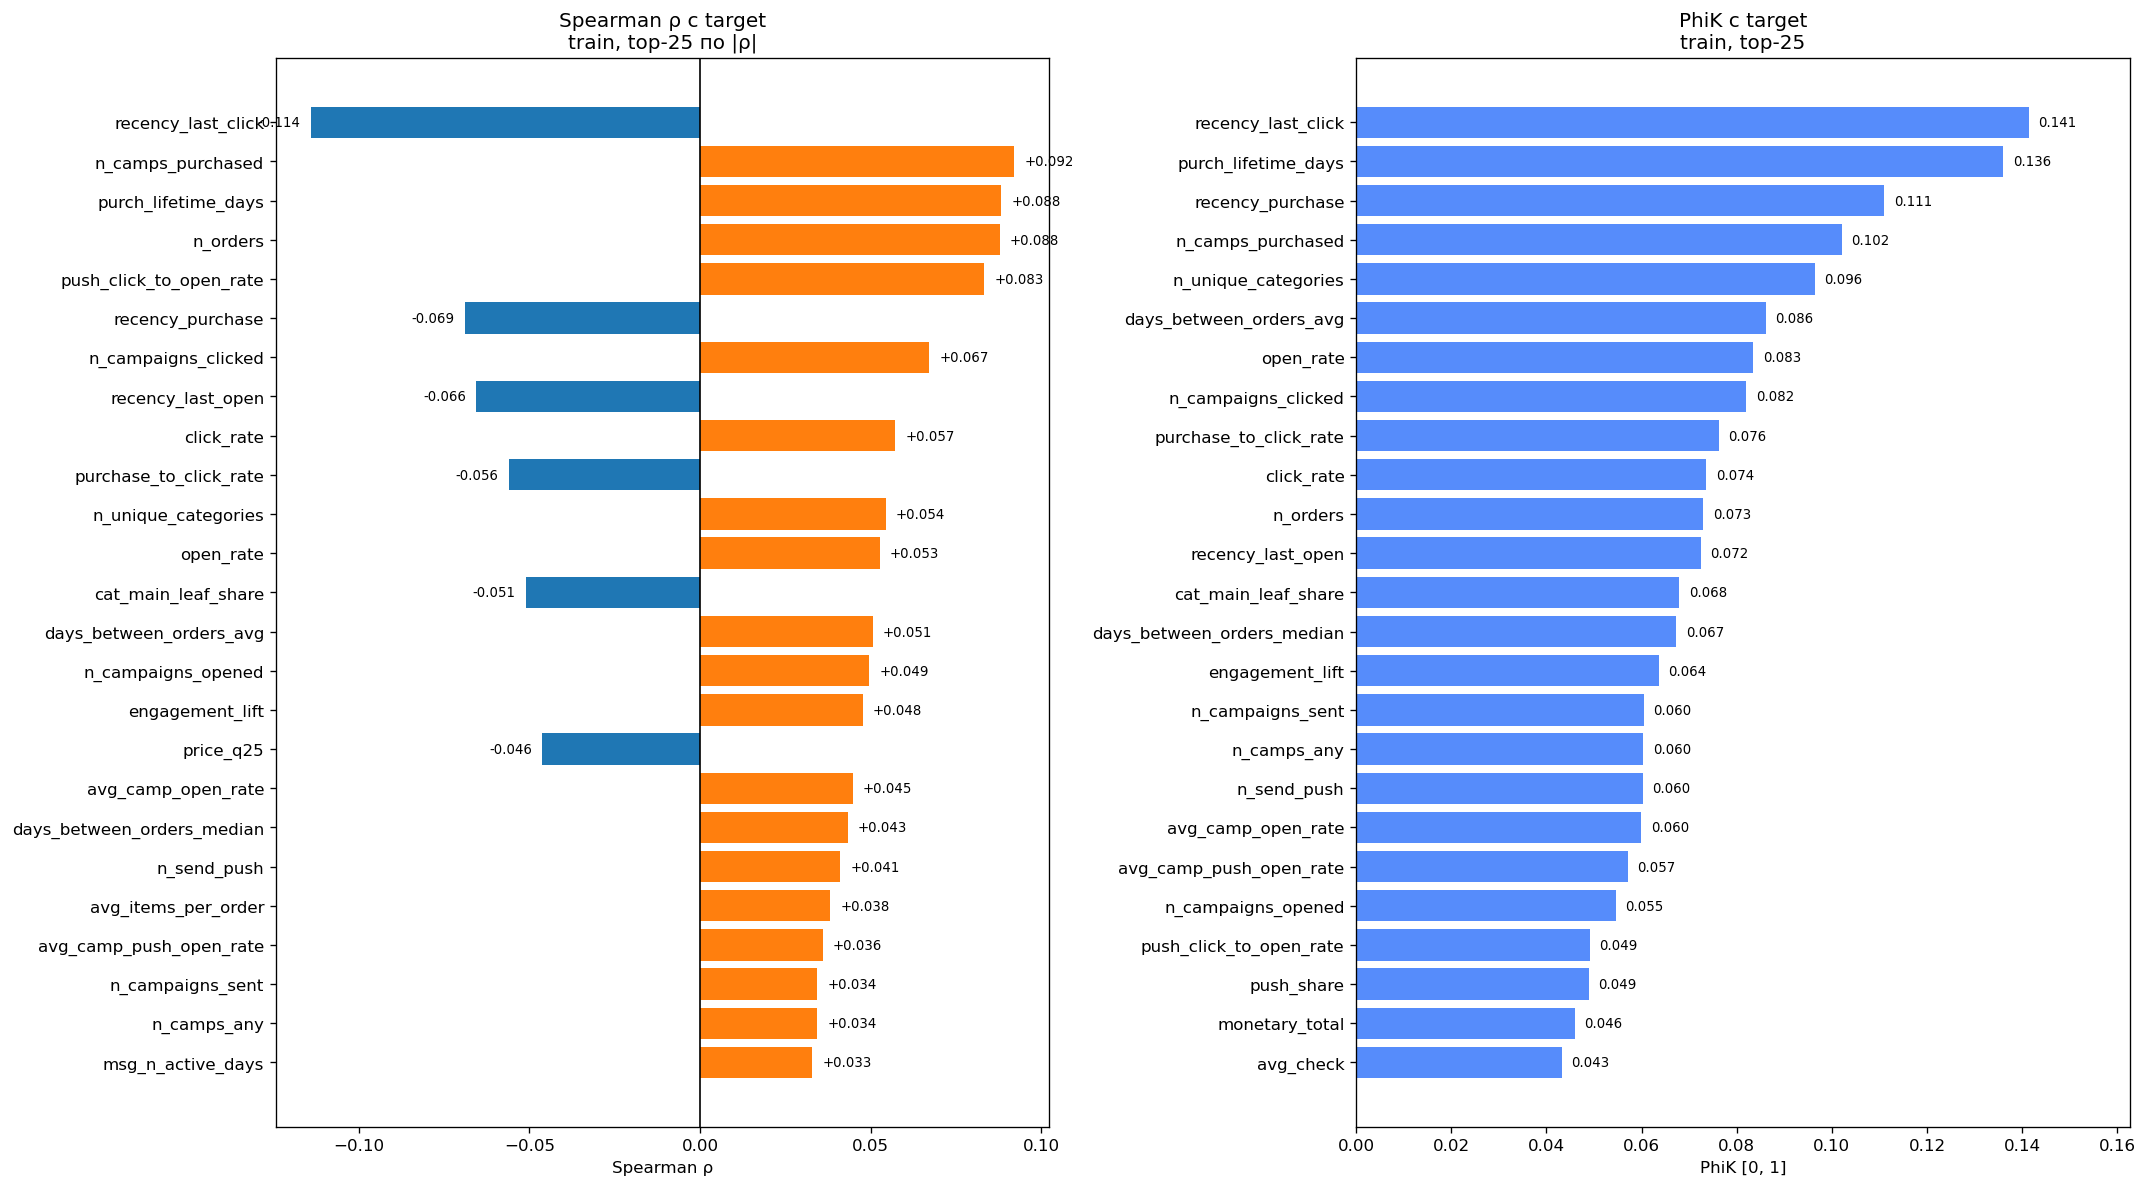

In [31]:
# =============================================================================
# Визуализация зависимостей признаков и target
# =============================================================================
top_n = 25

# ── Данные для графиков ───────────────────────────────────────────────────────
spearman_plot = (
    corr_target
    .reindex(corr_target.abs().sort_values(ascending=False).head(top_n).index)
    .sort_values(key=lambda x: x.abs(), ascending=True)
)

phik_target_plot = (
    phik_target
    .sort_values(ascending=False)
    .head(top_n)
    .sort_values(ascending=True)
)

# ── Два графика рядом ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(18, 10),
    dpi=120
)

# =============================================================================
# 1. Spearman с target
# =============================================================================

colors = spearman_plot.apply(lambda x: "tab:orange" if x > 0 else "tab:blue")

axes[0].barh(
    spearman_plot.index,
    spearman_plot.values,
    color=colors
)

axes[0].axvline(0, color="black", linewidth=1)

axes[0].set_title("Spearman ρ с target\ntrain, top-25 по |ρ|")
axes[0].set_xlabel("Spearman ρ")
axes[0].set_ylabel("")

for i, value in enumerate(spearman_plot.values):
    ha = "left" if value >= 0 else "right"
    x_offset = 0.003 if value >= 0 else -0.003

    axes[0].text(
        value + x_offset,
        i,
        f"{value:+.3f}",
        va="center",
        ha=ha,
        fontsize=8
    )


# =============================================================================
# 2. PhiK с target
# =============================================================================

axes[1].barh(
    phik_target_plot.index,
    phik_target_plot.values
)

axes[1].set_title("PhiK с target\ntrain, top-25")
axes[1].set_xlabel("PhiK [0, 1]")
axes[1].set_ylabel("")

for i, value in enumerate(phik_target_plot.values):
    axes[1].text(
        value + 0.002,
        i,
        f"{value:.3f}",
        va="center",
        ha="left",
        fontsize=8
    )

axes[1].set_xlim(0, max(phik_target_plot.max() * 1.15, 0.05))

plt.tight_layout()
plt.show()

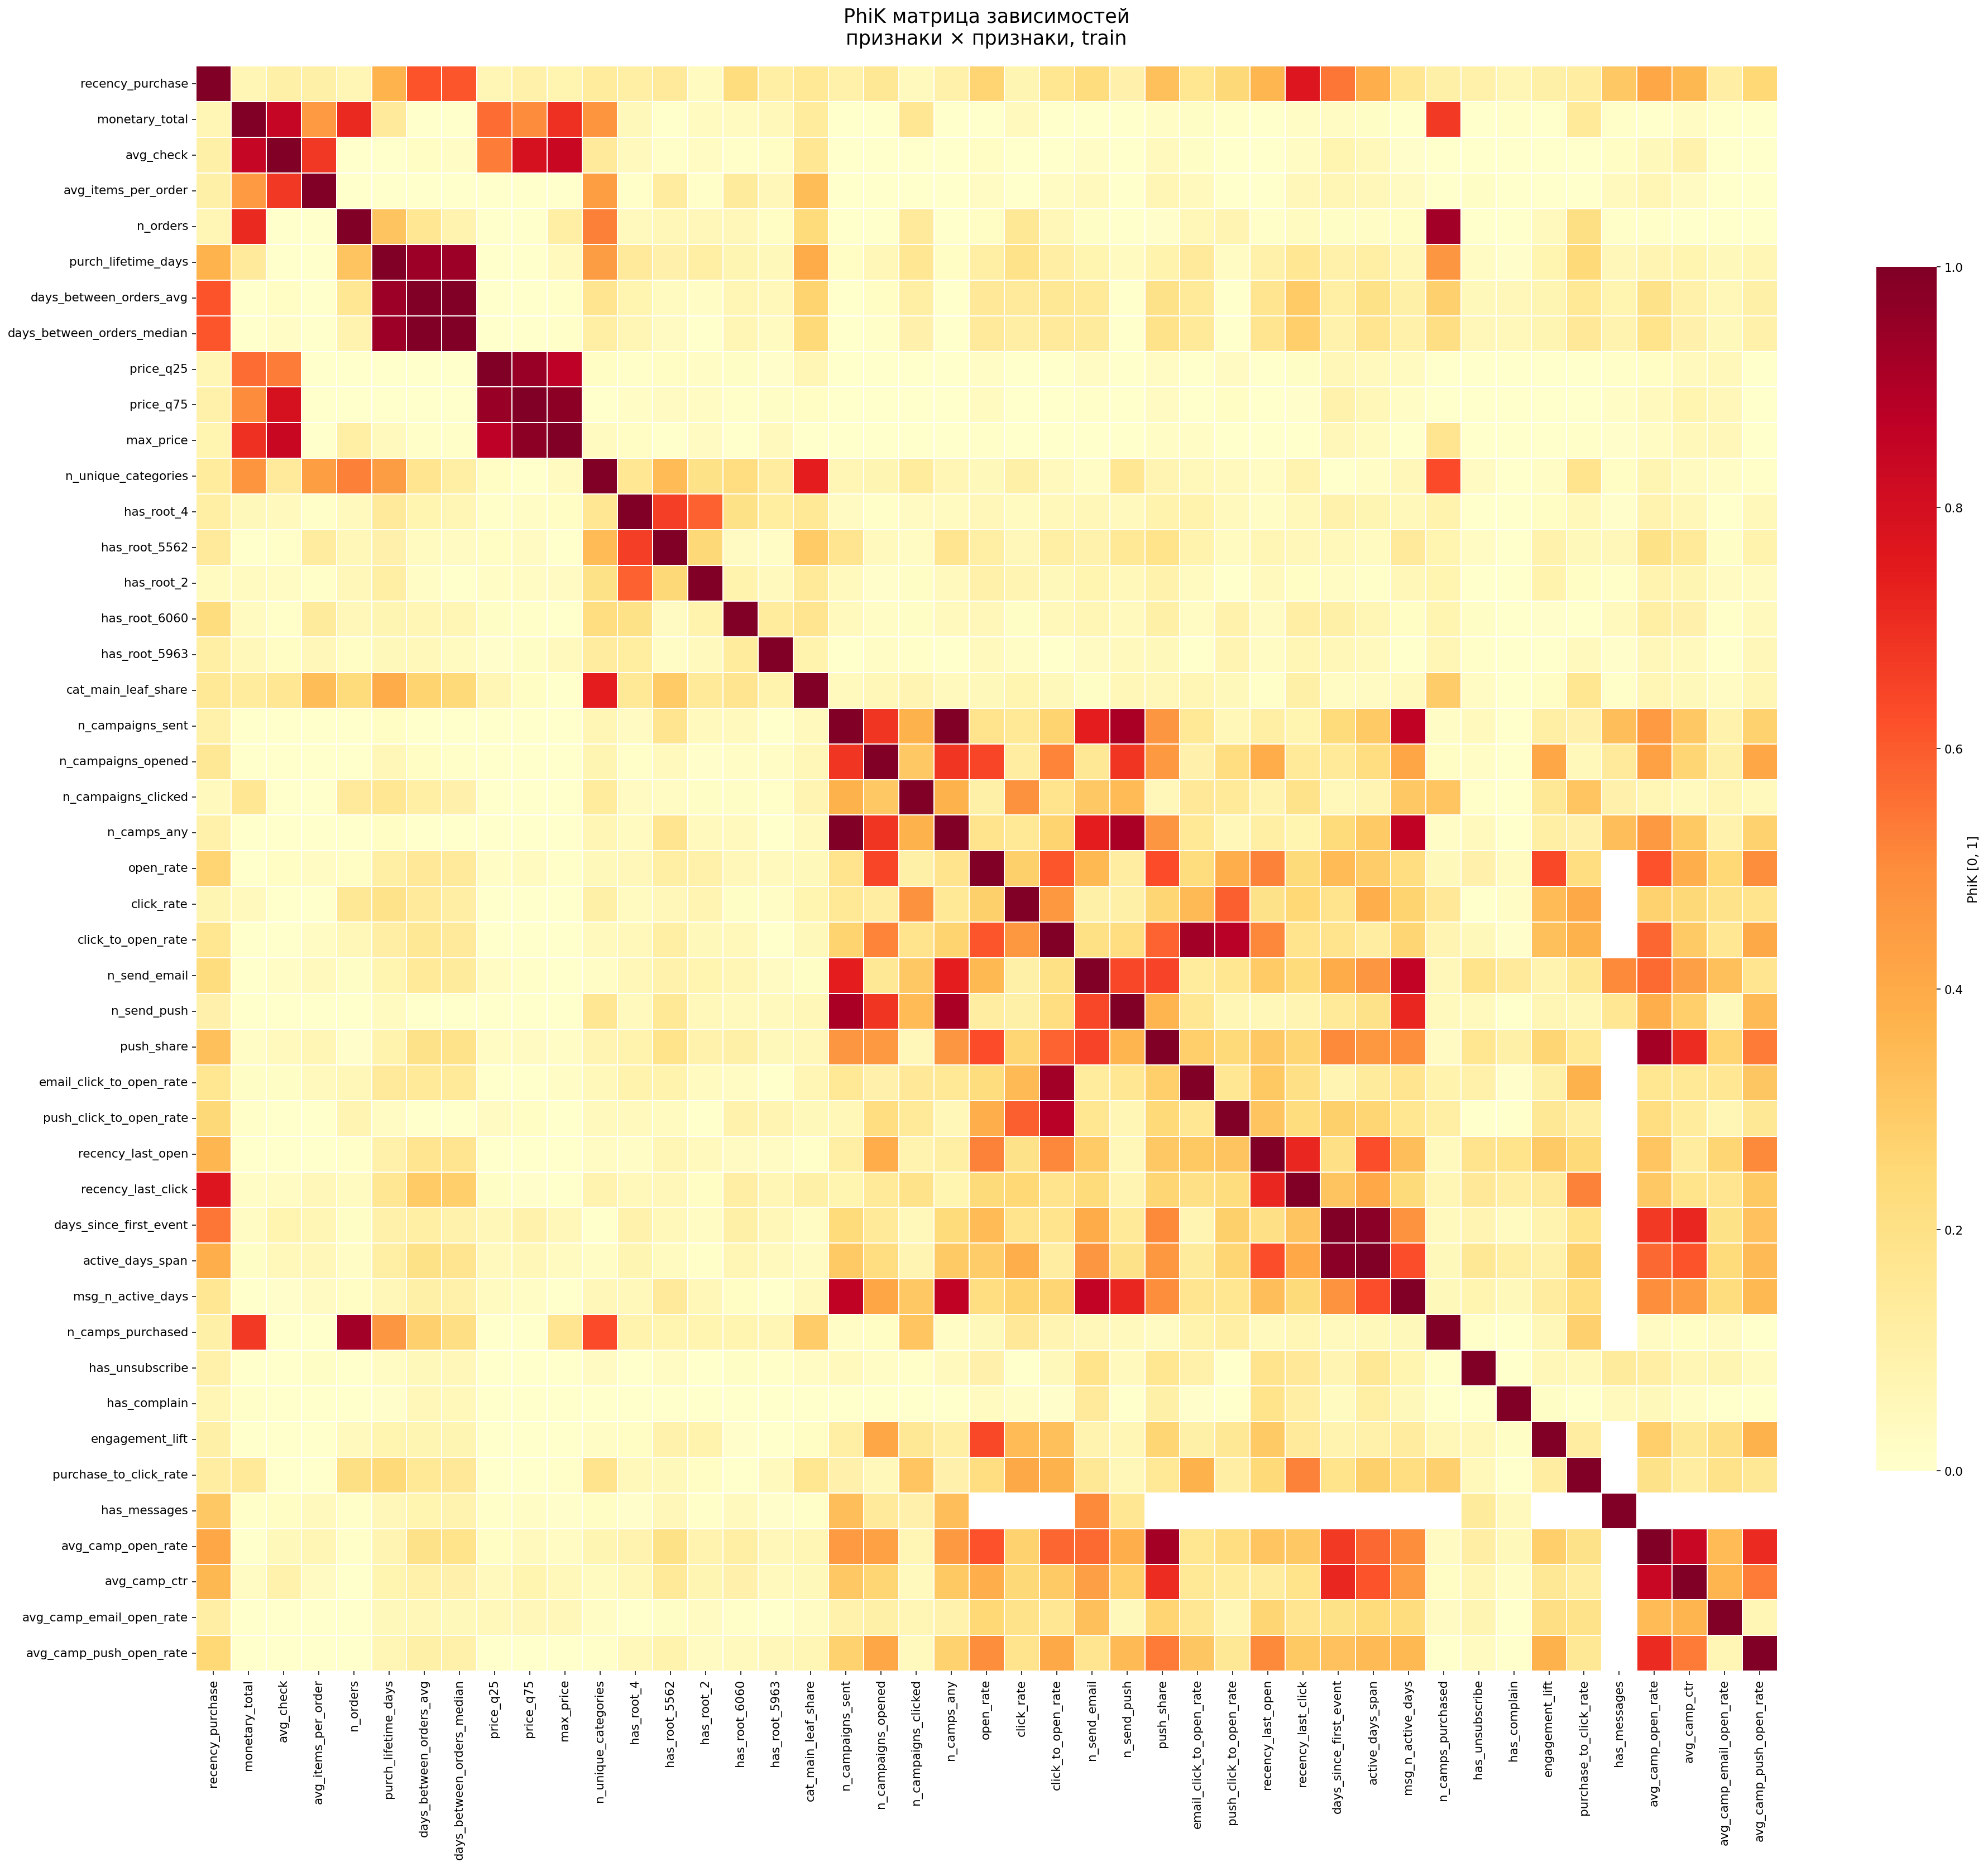

In [32]:
# =============================================================================
# PhiK-матрица зависимостей между признаками
# =============================================================================

plt.figure(figsize=(28, 24), dpi=140)

ax = sns.heatmap(
    phik_matrix,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    square=False,
    linewidths=0.15,
    linecolor="white",
    cbar_kws={
        "label": "PhiK [0, 1]",
        "shrink": 0.75
    }
)

ax.set_title(
    "PhiK матрица зависимостей\nпризнаки × признаки, train",
    fontsize=18,
    pad=20
)

# Увеличиваем подписи признаков
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90,
    ha="center",
    fontsize=11
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=11
)

# Увеличиваем подписи шкалы справа
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=11)
cbar.set_label("PhiK [0, 1]", fontsize=12)

plt.tight_layout()
plt.show()

### 4.7 Анализ признаков и стратегия моделирования

#### Корреляция с целевой переменной

Для оценки связи признаков с целевой переменной были рассчитаны две метрики:

- **Spearman** — ранговая корреляция, хорошо показывает монотонную связь
  между признаком и целевой переменной;
- **PhiK** — более универсальная мера зависимости, которая выявляет
  как линейные, так и нелинейные связи.

По результатам обеих метрик наиболее информативными оказались признаки,
связанные с недавней активностью клиента, историей покупок и реакцией
на маркетинговые кампании.

| Признак | Spearman | PhiK | Интерпретация |
|---|---:|---:|---|
| `recency_last_click` | -0.114 | 0.141 | Чем меньше времени прошло с последнего клика, тем выше вероятность покупки |
| `purch_lifetime_days` | +0.088 | 0.136 | Клиенты с более длинной историей покупок чаще совершают повторные покупки |
| `recency_purchase` | -0.069 | 0.111 | Чем меньше времени прошло с последней покупки, тем выше вероятность новой |
| `n_camps_purchased` | +0.092 | 0.102 | Число кампаний, связанных с покупками клиента, коррелирует с активностью |
| `n_unique_categories` | +0.055 | 0.097 | Более широкий товарный интерес связан с большей покупательской активностью |

Признаки с нулевой или почти нулевой связью с `target` по PhiK:
`price_q25`, `price_q75`, `has_complain`, `has_root_2`, `avg_items_per_order`.

#### Мультиколлинеарность

PhiK-матрица выявила несколько групп сильно связанных признаков.
Для tree-based моделей такая мультиколлинеарность обычно не критична:
модель выбирает лучший признак из группы при построении разбиений.
Для Logistic Regression мультиколлинеарность частично компенсируется
L2-регуляризацией, но может ухудшать интерпретируемость коэффициентов.

Явные дубли и признаки с почти полной зависимостью исключены из
финального набора:

| Удаляем | Оставляем | PhiK | Причина |
|---|---|---:|---|
| `n_camps_any` | `n_campaigns_sent` | 1.000 | Признаки практически идентичны |
| `days_between_orders_median` | `days_between_orders_avg` | 1.000 | Среднее и медиана интервала между заказами несут одинаковую информацию |
| `active_days_span` | `days_since_first_event` | 0.976 | Смысловой дубль: оба признака описывают длительность истории взаимодействия |
| `max_price` | `price_q75` | 0.971 | Оба описывают верхний ценовой сегмент клиента |

Дополнительно исключаются признаки с нулевой или почти нулевой связью
с целевой переменной:
`price_q25`, `has_complain`, `has_root_2`, `avg_items_per_order`.

Граничные случаи оставлены до этапа обучения моделей:

- `n_camps_purchased` и `n_orders` сильно связаны (PhiK=0.926), но несут
  разный смысл: общее число заказов и число кампаний, связанных с покупками.
- `price_q75` и `avg_check` также связаны (PhiK=0.793), но описывают
  разные аспекты: ценовой сегмент товаров и средний чек заказа.

#### Финальный набор признаков

После исключения дублей и признаков с низкой информативностью
в моделях используется **37 признаков**.

```python
DROP_COLS = [
    "n_camps_any",                # дубль n_campaigns_sent
    "days_between_orders_median", # дубль days_between_orders_avg
    "active_days_span",           # дубль days_since_first_event
    "max_price",                  # сильная связь с price_q75
    "price_q25",                  # PhiK с target ≈ 0
    "has_complain",               # PhiK с target ≈ 0
    "has_root_2",                 # PhiK с target ≈ 0
    "avg_items_per_order",        # PhiK с target ≈ 0
]
```

#### Стратегия обработки пропусков

В матрице признаков присутствуют структурные пропуски, отражающие
отсутствие определённого клиентского опыта:

- `days_between_orders_avg` не определён для клиентов с единственным
  заказом или без покупок до CUTOFF (85.7% клиентов);
- `recency_last_open`, `recency_last_click`, rate-признаки по каналам
  не определены для клиентов без соответствующих событий;
- признаки качества кампаний отсутствуют у клиентов без маркетинговых
  контактов.

#### Стратегия моделирования

Для сравнения обучаются четыре модели в порядке возрастания сложности,
что позволяет отследить прогрессию качества.

**Logistic Regression (baseline):**

- базовая линейная модель для интерпретируемого нижнего порога качества;
- Pipeline: `SimpleImputer(strategy="median", add_indicator=True)` →
  log1p-трансформация скошенных признаков (`monetary_total`, `avg_check`,
  `n_campaigns_*`, `recency_*`, `n_send_*`) →
  `StandardScaler` →
  `LogisticRegression(class_weight="balanced")`;
- L2-регуляризация контролирует переобучение и частично компенсирует
  остаточную мультиколлинеарность.

**LightGBM:**

- градиентный бустинг, оптимизированный по скорости;
- NaN обрабатываются нативно, масштабирование не требуется;
- `scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() ≈ 51.9`.

**CatBoost:**

- градиентный бустинг, оптимизированный для категориальных
  признаков и несбалансированных данных;
- NaN обрабатываются нативно, масштабирование не требуется;
- `class_weights={0: 1, 1: 51.9}` для компенсации дисбаланса.

**Stacking (финальная модель):**

- ансамбль двух уровней: базовые модели предсказывают вероятности,
  мета-модель обучается их комбинировать;
- базовые модели: LogReg + LightGBM + CatBoost;
- мета-модель: `LogisticRegression(class_weight="balanced")`;
- кросс-валидация базовых моделей: `StratifiedKFold(n_splits=5)`,
  чтобы мета-модель не обучалась на тех же данных что и базовые;
- основная метрика: **ROC-AUC**.

### 4.8 Финальный набор признаков

In [33]:
# =============================================================================
# Финальный набор признаков
# =============================================================================

DROP_COLS = [
    "n_camps_any",                # дубль n_campaigns_sent (PhiK=1.0)
    "days_between_orders_median", # дубль days_between_orders_avg (PhiK=1.0)
    "active_days_span",           # дубль days_since_first_event (PhiK=0.976)
    "max_price",                  # сильная связь с price_q75 (PhiK=0.971)
    "price_q25",                  # PhiK с target ≈ 0
    "has_complain",               # PhiK с target ≈ 0
    "has_root_2",                 # PhiK с target ≈ 0
    "avg_items_per_order",        # PhiK с target ≈ 0
]

FEATURE_COLS = [
    c for c in fm.columns
    if c not in ["client_id", "target"] + DROP_COLS
]

X       = fm[FEATURE_COLS]
y       = fm["target"]
X_train = X_train.drop(columns=DROP_COLS, errors="ignore")
X_test  = X_test.drop(columns=DROP_COLS, errors="ignore")

# ── Валидация ─────────────────────────────────────────────────────────────────
assert X_train.shape[1] == len(FEATURE_COLS), "Несоответствие числа признаков"
assert X_test.shape[1]  == len(FEATURE_COLS), "Несоответствие числа признаков"

print(f"  Признаков итого:   {len(FEATURE_COLS)}")
print(f"  Дропнуто:          {len(DROP_COLS)}")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")

print(f"\n  Финальные признаки:")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"    {i:>2}. {col}")


  Признаков итого:   37
  Дропнуто:          8
  X_train: (39879, 37)
  X_test:  (9970, 37)

  Финальные признаки:
     1. recency_purchase
     2. monetary_total
     3. avg_check
     4. n_orders
     5. purch_lifetime_days
     6. days_between_orders_avg
     7. price_q75
     8. n_unique_categories
     9. has_root_4
    10. has_root_5562
    11. has_root_6060
    12. has_root_5963
    13. cat_main_leaf_share
    14. n_campaigns_sent
    15. n_campaigns_opened
    16. n_campaigns_clicked
    17. open_rate
    18. click_rate
    19. click_to_open_rate
    20. n_send_email
    21. n_send_push
    22. push_share
    23. email_click_to_open_rate
    24. push_click_to_open_rate
    25. recency_last_open
    26. recency_last_click
    27. days_since_first_event
    28. msg_n_active_days
    29. n_camps_purchased
    30. has_unsubscribe
    31. engagement_lift
    32. purchase_to_click_rate
    33. has_messages
    34. avg_camp_open_rate
    35. avg_camp_ctr
    36. avg_camp_email_open_ra

<a id="sec5"></a>
## 5. Обучение и оценка моделей

### 5.1 Baseline: Logistic Regression

In [34]:
# =============================================================================
# Cell 46 — Хранилище результатов моделей
# =============================================================================

# Словарь для сохранения результатов всех моделей.
# Заполняется по мере обучения — используется в финальном сравнении.
results = {}

=== Baseline: Logistic Regression ===

  Фолд      ROC-AUC
  ------------------
  Fold 1      0.7674
  Fold 2      0.7420
  Fold 3      0.7655
  Fold 4      0.7326
  Fold 5      0.7763
  ------------------
  Mean       0.7567
  Std        0.0166

  Время CV:   1.3 сек
  Время fit:  0.4 сек


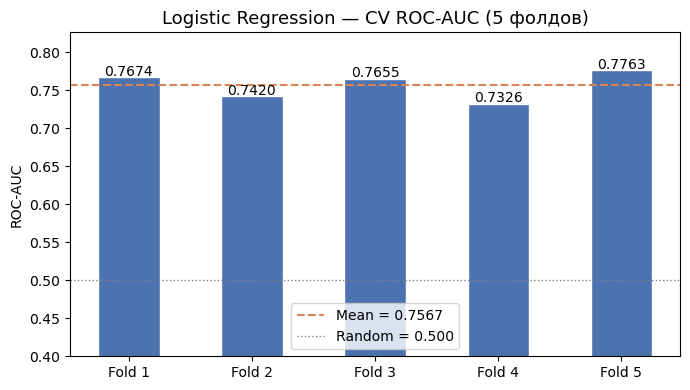

CPU times: user 1.11 s, sys: 121 ms, total: 1.23 s
Wall time: 1.76 s


In [35]:
%%time
# =============================================================================
# Baseline: Logistic Regression
# =============================================================================

# ── Скошенные признаки — применяем log1p ─────────────────────────────────────
LOG1P_COLS = [
    "monetary_total", "avg_check", "n_campaigns_sent", "n_campaigns_opened",
    "n_campaigns_clicked", "n_send_email", "n_send_push", "msg_n_active_days",
    "recency_purchase", "recency_last_open", "recency_last_click",
    "days_since_first_event", "purch_lifetime_days", "days_between_orders_avg",
    "n_camps_purchased"
]
LOG1P_COLS = [c for c in LOG1P_COLS if c in FEATURE_COLS]

def log1p_selected(X):
    """Применяет log1p к скошенным признакам, остальные оставляет без изменений."""
    X = X.copy()
    for col in LOG1P_COLS:
        if col in X.columns:
            X[col] = np.log1p(X[col].clip(lower=0))
    return X

# ── Pipeline ──────────────────────────────────────────────────────────────────
pipe_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("log1p",   FunctionTransformer(
                    lambda X: log1p_selected(pd.DataFrame(X)),
                    validate=False)),
    ("scaler",  StandardScaler()),
    ("model",   LogisticRegression(
                    class_weight="balanced",
                    max_iter=1000,
                    random_state=RANDOM_STATE,
                    n_jobs=-1))
])

# ── Кросс-валидация на train ──────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

t_start   = time.perf_counter()
cv_scores = cross_val_score(
    pipe_lr, X_train, y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)
cv_time = time.perf_counter() - t_start

# ── Финальное обучение на всём train ─────────────────────────────────────────
t_start = time.perf_counter()
pipe_lr.fit(X_train, y_train)
fit_time = time.perf_counter() - t_start

# ── Вывод ─────────────────────────────────────────────────────────────────────
print("=== Baseline: Logistic Regression ===\n")
print(f"  {'Фолд':<8} {'ROC-AUC':>8}")
print("  " + "-" * 18)
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i:<3}  {s:>8.4f}")
print("  " + "-" * 18)
print(f"  {'Mean':<8} {cv_scores.mean():>8.4f}")
print(f"  {'Std':<8} {cv_scores.std():>8.4f}")
print(f"\n  Время CV:   {cv_time:.1f} сек")
print(f"  Время fit:  {fit_time:.1f} сек")

# ── Визуализация ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    [f"Fold {i}" for i in range(1, 6)],
    cv_scores,
    color="#4C72B0",
    width=0.5,
    edgecolor="white"
)
ax.axhline(cv_scores.mean(), color="#DD8452", linestyle="--",
           linewidth=1.5, label=f"Mean = {cv_scores.mean():.4f}")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1,
           label="Random = 0.500")

for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{val:.4f}", ha="center", fontsize=10)

ax.set_ylim(0.4, min(1.0, cv_scores.max() + 0.05))
ax.set_ylabel("ROC-AUC")
ax.set_title("Logistic Regression — CV ROC-AUC (5 фолдов)", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

# ── Сохраняем результат ───────────────────────────────────────────────────────
results["LogReg"] = {
    "cv_mean":   cv_scores.mean(),
    "cv_std":    cv_scores.std(),
    "cv_scores": cv_scores,
    "cv_time":   cv_time,
    "fit_time":  fit_time,
    "pipeline":  pipe_lr
}


### 5.2 LightGBM

  scale_pos_weight = 50.9

=== LightGBM ===

  Фолд      ROC-AUC
  ------------------
  Fold 1      0.7196
  Fold 2      0.6876
  Fold 3      0.6766
  Fold 4      0.6392
  Fold 5      0.6951
  ------------------
  Mean       0.6836
  Std        0.0263

  Время CV:   10.9 сек
  Время fit:  3.6 сек


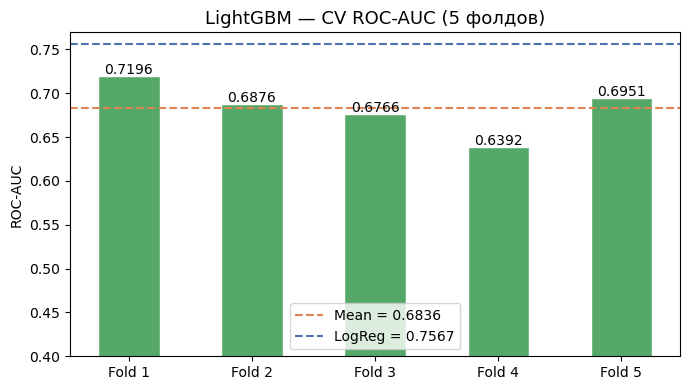

CPU times: user 3.82 s, sys: 3.68 s, total: 7.5 s
Wall time: 14.6 s


In [36]:
%%time
# =============================================================================
# Cell 49 — LightGBM
# =============================================================================

SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()
print(f"  scale_pos_weight = {SCALE_POS_WEIGHT:.1f}")

# ── Pipeline ──────────────────────────────────────────────────────────────────
pipe_lgbm = Pipeline([
    ("model", lgb.LGBMClassifier(
        scale_pos_weight=SCALE_POS_WEIGHT,
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    ))
])

# ── Кросс-валидация на train ──────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

t_start   = time.perf_counter()
cv_scores = cross_val_score(
    pipe_lgbm, X_train, y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)
cv_time = time.perf_counter() - t_start

# ── Финальное обучение на всём train ─────────────────────────────────────────
t_start = time.perf_counter()
pipe_lgbm.fit(X_train, y_train)
fit_time = time.perf_counter() - t_start

# ── Вывод ─────────────────────────────────────────────────────────────────────
print("\n=== LightGBM ===\n")
print(f"  {'Фолд':<8} {'ROC-AUC':>8}")
print("  " + "-" * 18)
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i:<3}  {s:>8.4f}")
print("  " + "-" * 18)
print(f"  {'Mean':<8} {cv_scores.mean():>8.4f}")
print(f"  {'Std':<8} {cv_scores.std():>8.4f}")
print(f"\n  Время CV:   {cv_time:.1f} сек")
print(f"  Время fit:  {fit_time:.1f} сек")

# ── Визуализация ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    [f"Fold {i}" for i in range(1, 6)],
    cv_scores,
    color="#55A868",
    width=0.5,
    edgecolor="white"
)
ax.axhline(cv_scores.mean(), color="#DD8452", linestyle="--",
           linewidth=1.5, label=f"Mean = {cv_scores.mean():.4f}")
ax.axhline(results["LogReg"]["cv_mean"], color="#4C72B0", linestyle="--",
           linewidth=1.5, label=f"LogReg = {results['LogReg']['cv_mean']:.4f}")

for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{val:.4f}", ha="center", fontsize=10)

ax.set_ylim(0.4, min(1.0, cv_scores.max() + 0.05))
ax.set_ylabel("ROC-AUC")
ax.set_title("LightGBM — CV ROC-AUC (5 фолдов)", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

# ── Сохраняем результат ───────────────────────────────────────────────────────
results["LightGBM"] = {
    "cv_mean":   cv_scores.mean(),
    "cv_std":    cv_scores.std(),
    "cv_scores": cv_scores,
    "cv_time":   cv_time,
    "fit_time":  fit_time,
    "pipeline":  pipe_lgbm
}


### 5.2.1 LightGBM — подбор гиперпараметров (Optuna)

Дефолтная конфигурация LightGBM дала CV ROC-AUC = 0.6836 — ниже baseline LogReg (0.7568).
Для поиска оптимальных гиперпараметров используется Optuna с байесовской оптимизацией.
50 итераций с 5-фолдовой стратифицированной кросс-валидацией на train.

  0%|          | 0/50 [00:00<?, ?it/s]


=== Optuna LightGBM — лучший результат ===

  CV ROC-AUC:  0.7652
  vs baseline: 0.7567

  Лучшие параметры:
    n_estimators              207
    learning_rate             0.010579487980568281
    num_leaves                22
    min_child_samples         25
    subsample                 0.8730944504866547
    colsample_bytree          0.5027292876886565
    reg_alpha                 1.4596474028247443e-07
    reg_lambda                2.3195256355194683e-07

  Фолд      ROC-AUC
  ------------------
  Fold 1      0.7867
  Fold 2      0.7510
  Fold 3      0.7687
  Fold 4      0.7408
  Fold 5      0.7787
  ------------------
  Mean       0.7652
  Std        0.0170

  Время CV:     4.1 сек
  Время fit:    1.4 сек


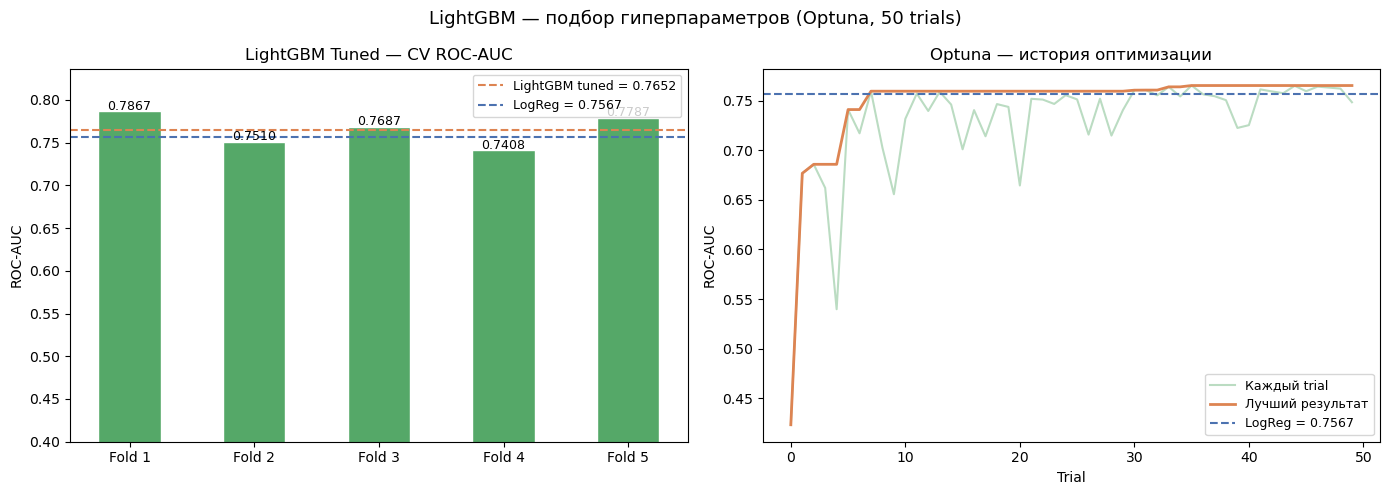


✓ Cell Optuna LightGBM OK
CPU times: user 3.31 s, sys: 3.68 s, total: 6.98 s
Wall time: 5min 23s


In [37]:
%%time
# =============================================================================
# LightGBM: подбор гиперпараметров через Optuna
# =============================================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective_lgbm(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 500),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 15, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }
    model = lgb.LGBMClassifier(
        scale_pos_weight=SCALE_POS_WEIGHT,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
        **params
    )
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring="roc_auc", n_jobs=-1
    )
    return scores.mean()

study_lgbm = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)

# ── Лучшие параметры ──────────────────────────────────────────────────────────
best_params_lgbm = study_lgbm.best_params
print(f"\n=== Optuna LightGBM — лучший результат ===\n")
print(f"  CV ROC-AUC:  {study_lgbm.best_value:.4f}")
print(f"  vs baseline: {results['LogReg']['cv_mean']:.4f}")
print(f"\n  Лучшие параметры:")
for k, v in best_params_lgbm.items():
    print(f"    {k:<25} {v}")

# ── Финальное обучение с лучшими параметрами ─────────────────────────────────
t_start = time.perf_counter()
pipe_lgbm_tuned = Pipeline([
    ("model", lgb.LGBMClassifier(
        scale_pos_weight=SCALE_POS_WEIGHT,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
        **best_params_lgbm
    ))
])

cv_scores = cross_val_score(
    pipe_lgbm_tuned, X_train, y_train,
    cv=cv, scoring="roc_auc", n_jobs=-1
)
cv_time = time.perf_counter() - t_start

t_start = time.perf_counter()
pipe_lgbm_tuned.fit(X_train, y_train)
fit_time = time.perf_counter() - t_start

# ── Вывод ─────────────────────────────────────────────────────────────────────
print(f"\n  {'Фолд':<8} {'ROC-AUC':>8}")
print("  " + "-" * 18)
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i:<3}  {s:>8.4f}")
print("  " + "-" * 18)
print(f"  {'Mean':<8} {cv_scores.mean():>8.4f}")
print(f"  {'Std':<8} {cv_scores.std():>8.4f}")
print(f"\n  Время CV:     {cv_time:.1f} сек")
print(f"  Время fit:    {fit_time:.1f} сек")

# ── Визуализация ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(
    [f"Fold {i}" for i in range(1, 6)],
    cv_scores,
    color="#55A868", width=0.5, edgecolor="white"
)
axes[0].axhline(cv_scores.mean(), color="#DD8452", linestyle="--",
                linewidth=1.5, label=f"LightGBM tuned = {cv_scores.mean():.4f}")
axes[0].axhline(results["LogReg"]["cv_mean"], color="#4C72B0", linestyle="--",
                linewidth=1.5, label=f"LogReg = {results['LogReg']['cv_mean']:.4f}")
for bar, val in zip(bars, cv_scores):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.002,
                 f"{val:.4f}", ha="center", fontsize=9)
axes[0].set_ylim(0.4, min(1.0, cv_scores.max() + 0.05))
axes[0].set_ylabel("ROC-AUC")
axes[0].set_title("LightGBM Tuned — CV ROC-AUC", fontsize=12)
axes[0].legend(fontsize=9)

trial_values = [t.value for t in study_lgbm.trials]
axes[1].plot(trial_values, alpha=0.4, color="#55A868", label="Каждый trial")
axes[1].plot(
    [max(trial_values[:i+1]) for i in range(len(trial_values))],
    color="#DD8452", linewidth=2, label="Лучший результат"
)
axes[1].axhline(results["LogReg"]["cv_mean"], color="#4C72B0",
                linestyle="--", linewidth=1.5,
                label=f"LogReg = {results['LogReg']['cv_mean']:.4f}")
axes[1].set_xlabel("Trial")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("Optuna — история оптимизации", fontsize=12)
axes[1].legend(fontsize=9)

plt.suptitle("LightGBM — подбор гиперпараметров (Optuna, 50 trials)", fontsize=13)
plt.tight_layout()
plt.show()

# ── Сохраняем результат ───────────────────────────────────────────────────────
results["LightGBM_tuned"] = {
    "cv_mean":   cv_scores.mean(),
    "cv_std":    cv_scores.std(),
    "cv_scores": cv_scores,
    "cv_time":   cv_time,
    "fit_time":  fit_time,
    "pipeline":  pipe_lgbm_tuned,
    "best_params": best_params_lgbm
}

print("\n✓ Cell Optuna LightGBM OK")

### 5.3 CatBoost — подбор гиперпараметров (Optuna)

  0%|          | 0/50 [00:00<?, ?it/s]


=== Optuna CatBoost — лучший результат ===

  CV ROC-AUC:     0.7702
  vs LogReg:      0.7567
  vs LGBM tuned:  0.7652

  Лучшие параметры:
    iterations                410
    learning_rate             0.014145195849624419
    depth                     4
    l2_leaf_reg               5.616807690677292
    subsample                 0.657372155070297
    colsample_bylevel         0.9074813678578367
    min_data_in_leaf          37

  Фолд      ROC-AUC
  ------------------
  Fold 1      0.7855
  Fold 2      0.7553
  Fold 3      0.7709
  Fold 4      0.7488
  Fold 5      0.7903
  ------------------
  Mean       0.7702
  Std        0.0162

  Время CV:     11.6 сек
  Время fit:    1.6 сек


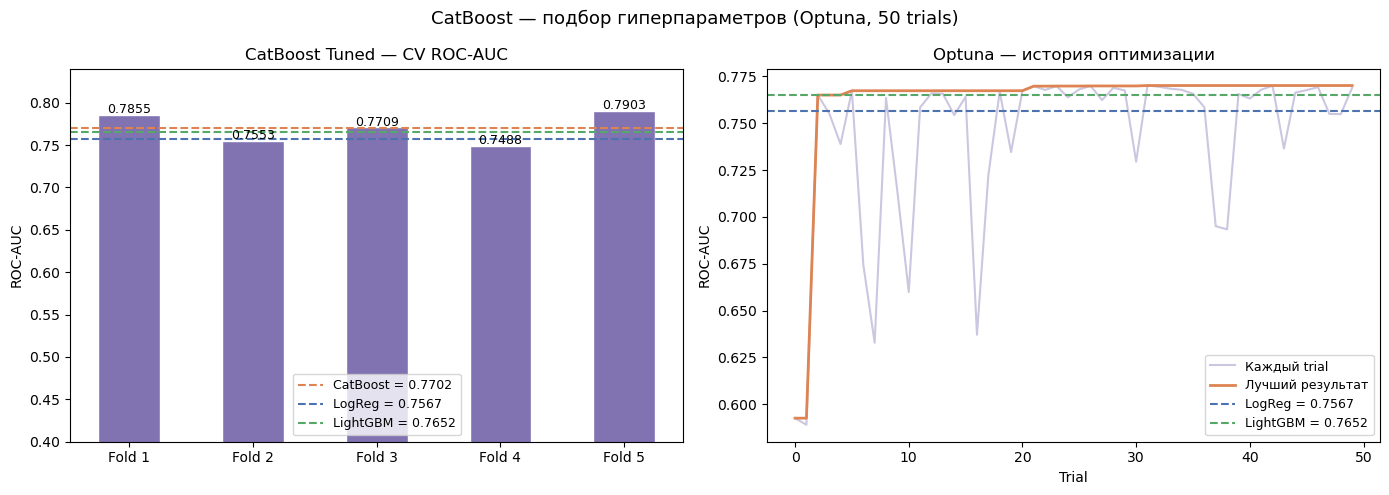


✓ CatBoost OK
CPU times: user 22min 1s, sys: 4min 6s, total: 26min 7s
Wall time: 9min 7s


In [38]:
%%time
# =============================================================================
#CatBoost: подбор гиперпараметров через Optuna
# =============================================================================

cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SPW = float(SCALE_POS_WEIGHT)

def objective_cb(trial):
    params = {
        "iterations":        trial.suggest_int("iterations", 100, 500),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth":             trial.suggest_int("depth", 3, 8),
        "l2_leaf_reg":       trial.suggest_float("l2_leaf_reg", 1e-8, 10.0, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "min_data_in_leaf":  trial.suggest_int("min_data_in_leaf", 5, 50),
    }
    model = CatBoostClassifier(
        scale_pos_weight=SPW,
        random_state=RANDOM_STATE,
        verbose=0,
        **params
    )
    # n_jobs убран — CatBoost не сериализуется через joblib/loky
    # параллелизм обеспечивается самим CatBoost внутри модели
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring="roc_auc"
    )
    return scores.mean()

study_cb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_cb.optimize(objective_cb, n_trials=50, show_progress_bar=True)

# ── Лучшие параметры ──────────────────────────────────────────────────────────
best_params_cb = study_cb.best_params
print(f"\n=== Optuna CatBoost — лучший результат ===\n")
print(f"  CV ROC-AUC:     {study_cb.best_value:.4f}")
print(f"  vs LogReg:      {results['LogReg']['cv_mean']:.4f}")
print(f"  vs LGBM tuned:  {results['LightGBM_tuned']['cv_mean']:.4f}")
print(f"\n  Лучшие параметры:")
for k, v in best_params_cb.items():
    print(f"    {k:<25} {v}")

# ── Финальное обучение с лучшими параметрами ─────────────────────────────────
pipe_cb_tuned = Pipeline([
    ("model", CatBoostClassifier(
        scale_pos_weight=SPW,
        random_state=RANDOM_STATE,
        verbose=0,
        **best_params_cb
    ))
])

t_start   = time.perf_counter()
cv_scores = cross_val_score(
    pipe_cb_tuned, X_train, y_train,
    cv=cv, scoring="roc_auc"
)
cv_time = time.perf_counter() - t_start

t_start  = time.perf_counter()
pipe_cb_tuned.fit(X_train, y_train)
fit_time = time.perf_counter() - t_start

# ── Вывод ─────────────────────────────────────────────────────────────────────
print(f"\n  {'Фолд':<8} {'ROC-AUC':>8}")
print("  " + "-" * 18)
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i:<3}  {s:>8.4f}")
print("  " + "-" * 18)
print(f"  {'Mean':<8} {cv_scores.mean():>8.4f}")
print(f"  {'Std':<8} {cv_scores.std():>8.4f}")
print(f"\n  Время CV:     {cv_time:.1f} сек")
print(f"  Время fit:    {fit_time:.1f} сек")

# ── Визуализация ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(
    [f"Fold {i}" for i in range(1, 6)],
    cv_scores,
    color="#8172B2", width=0.5, edgecolor="white"
)
axes[0].axhline(cv_scores.mean(), color="#DD8452", linestyle="--",
                linewidth=1.5, label=f"CatBoost = {cv_scores.mean():.4f}")
axes[0].axhline(results["LogReg"]["cv_mean"], color="#4C72B0", linestyle="--",
                linewidth=1.5, label=f"LogReg = {results['LogReg']['cv_mean']:.4f}")
axes[0].axhline(results["LightGBM_tuned"]["cv_mean"], color="#55A868", linestyle="--",
                linewidth=1.5, label=f"LightGBM = {results['LightGBM_tuned']['cv_mean']:.4f}")
for bar, val in zip(bars, cv_scores):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.002,
                 f"{val:.4f}", ha="center", fontsize=9)
axes[0].set_ylim(0.4, min(1.0, cv_scores.max() + 0.05))
axes[0].set_ylabel("ROC-AUC")
axes[0].set_title("CatBoost Tuned — CV ROC-AUC", fontsize=12)
axes[0].legend(fontsize=9)

trial_values = [t.value for t in study_cb.trials if t.value is not None]
axes[1].plot(trial_values, alpha=0.4, color="#8172B2", label="Каждый trial")
axes[1].plot(
    [max(trial_values[:i+1]) for i in range(len(trial_values))],
    color="#DD8452", linewidth=2, label="Лучший результат"
)
axes[1].axhline(results["LogReg"]["cv_mean"], color="#4C72B0",
                linestyle="--", linewidth=1.5,
                label=f"LogReg = {results['LogReg']['cv_mean']:.4f}")
axes[1].axhline(results["LightGBM_tuned"]["cv_mean"], color="#55A868",
                linestyle="--", linewidth=1.5,
                label=f"LightGBM = {results['LightGBM_tuned']['cv_mean']:.4f}")
axes[1].set_xlabel("Trial")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("Optuna — история оптимизации", fontsize=12)
axes[1].legend(fontsize=9)

plt.suptitle("CatBoost — подбор гиперпараметров (Optuna, 50 trials)", fontsize=13)
plt.tight_layout()
plt.show()

# ── Сохраняем результат ───────────────────────────────────────────────────────
results["CatBoost_tuned"] = {
    "cv_mean":     cv_scores.mean(),
    "cv_std":      cv_scores.std(),
    "cv_scores":   cv_scores,
    "cv_time":     cv_time,
    "fit_time":    fit_time,
    "pipeline":    pipe_cb_tuned,
    "best_params": best_params_cb
}

print("\n✓ CatBoost OK")

### 5.4 Стекинг

=== Stacking ===

  Фолд      ROC-AUC
  ------------------
  Fold 1      0.7909
  Fold 2      0.7568
  Fold 3      0.7753
  Fold 4      0.7505
  Fold 5      0.7906
  ------------------
  Mean       0.7728
  Std        0.0168

  Время CV:   130.4 сек
  Время fit:  24.1 сек


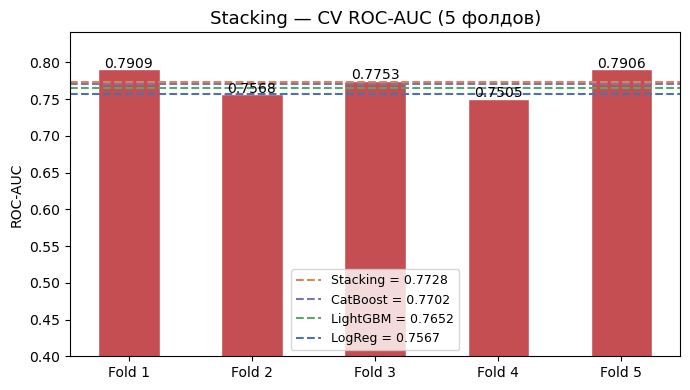


✓ Cell Stacking OK
CPU times: user 4min 19s, sys: 1min 20s, total: 5min 39s
Wall time: 2min 34s


In [39]:
%%time
# =============================================================================
# Stacking: LogReg + LightGBM + CatBoost → мета LogReg
# =============================================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pipe_stack = StackingClassifier(
    estimators=[
        ("logreg",   pipe_lr),
        ("lgbm",     pipe_lgbm_tuned),
        ("catboost", pipe_cb_tuned),
    ],
    final_estimator=LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    cv=cv,
    stack_method="predict_proba"
    # n_jobs убран — CatBoost не сериализуется через joblib/loky
)

# ── Кросс-валидация на train ──────────────────────────────────────────────────
# n_jobs убран из cross_val_score по той же причине
t_start   = time.perf_counter()
cv_scores = cross_val_score(
    pipe_stack, X_train, y_train,
    cv=cv, scoring="roc_auc"
)
cv_time = time.perf_counter() - t_start

# ── Финальное обучение на всём train ─────────────────────────────────────────
t_start = time.perf_counter()
pipe_stack.fit(X_train, y_train)
fit_time = time.perf_counter() - t_start

# ── Вывод ─────────────────────────────────────────────────────────────────────
print("=== Stacking ===\n")
print(f"  {'Фолд':<8} {'ROC-AUC':>8}")
print("  " + "-" * 18)
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i:<3}  {s:>8.4f}")
print("  " + "-" * 18)
print(f"  {'Mean':<8} {cv_scores.mean():>8.4f}")
print(f"  {'Std':<8} {cv_scores.std():>8.4f}")
print(f"\n  Время CV:   {cv_time:.1f} сек")
print(f"  Время fit:  {fit_time:.1f} сек")

# ── Визуализация ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    [f"Fold {i}" for i in range(1, 6)],
    cv_scores,
    color="#C44E52", width=0.5, edgecolor="white"
)
ax.axhline(cv_scores.mean(), color="#DD8452", linestyle="--",
           linewidth=1.5, label=f"Stacking = {cv_scores.mean():.4f}")
ax.axhline(results["CatBoost_tuned"]["cv_mean"], color="#8172B2", linestyle="--",
           linewidth=1.5, label=f"CatBoost = {results['CatBoost_tuned']['cv_mean']:.4f}")
ax.axhline(results["LightGBM_tuned"]["cv_mean"], color="#55A868", linestyle="--",
           linewidth=1.5, label=f"LightGBM = {results['LightGBM_tuned']['cv_mean']:.4f}")
ax.axhline(results["LogReg"]["cv_mean"], color="#4C72B0", linestyle="--",
           linewidth=1.5, label=f"LogReg = {results['LogReg']['cv_mean']:.4f}")

for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{val:.4f}", ha="center", fontsize=10)

ax.set_ylim(0.4, min(1.0, cv_scores.max() + 0.05))
ax.set_ylabel("ROC-AUC")
ax.set_title("Stacking — CV ROC-AUC (5 фолдов)", fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Сохраняем результат ───────────────────────────────────────────────────────
results["Stacking"] = {
    "cv_mean":   cv_scores.mean(),
    "cv_std":    cv_scores.std(),
    "cv_scores": cv_scores,
    "cv_time":   cv_time,
    "fit_time":  fit_time,
    "pipeline":  pipe_stack
}

print("\n✓ Cell Stacking OK")

### 5.5 Оценка финальной модели на тестовой выборке

По результатам кросс-валидации лучшей моделью является **Stacking**
(CV ROC-AUC = 0.7728). Тестовая выборка используется однократно
для получения финальной несмещённой оценки качества модели.

=== Финальная оценка: Stacking на тестовой выборке ===

  CV ROC-AUC (train):   0.7728 ± 0.0168
  Test ROC-AUC:         0.7810
  Расхождение CV/Test:  -0.0082


=== Сводная таблица CV ROC-AUC ===

  Модель                CV Mean   CV Std
  ----------------------------------------
  LogReg                 0.7567   0.0166
  LightGBM               0.6836   0.0263
  LightGBM_tuned         0.7652   0.0170
  CatBoost_tuned         0.7702   0.0162
  Stacking               0.7728   0.0168 ← финальная
  ----------------------------------------

  Test ROC-AUC (Stacking): 0.7810


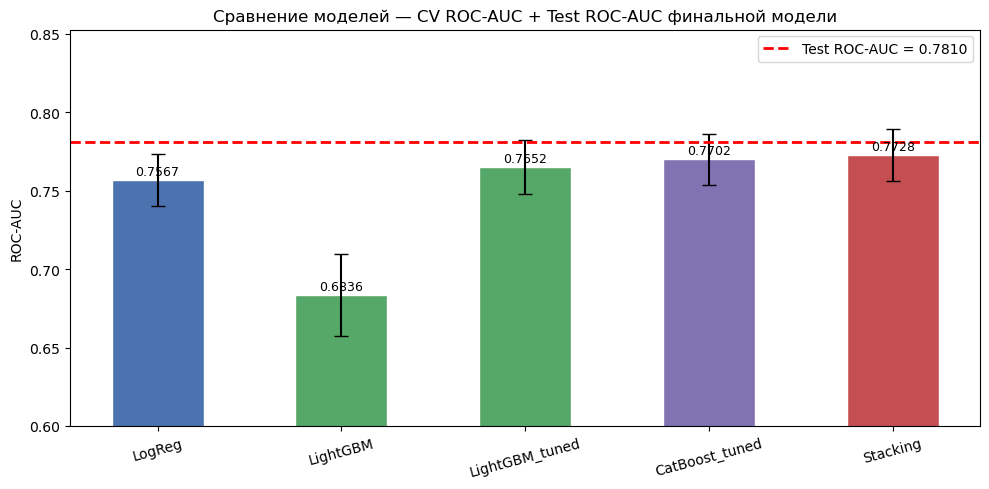

In [40]:
# =============================================================================
# Оценка финальной модели на тестовой выборке
# =============================================================================

# ── Финальная модель — Stacking ───────────────────────────────────────────────
y_pred_test = pipe_stack.predict_proba(X_test)[:, 1]
auc_test    = roc_auc_score(y_test, y_pred_test)

print("=== Финальная оценка: Stacking на тестовой выборке ===\n")
print(f"  CV ROC-AUC (train):   {results['Stacking']['cv_mean']:.4f} ± {results['Stacking']['cv_std']:.4f}")
print(f"  Test ROC-AUC:         {auc_test:.4f}")
print(f"  Расхождение CV/Test:  {results['Stacking']['cv_mean'] - auc_test:+.4f}")

# ── Сводная таблица CV по всем моделям ───────────────────────────────────────
print("\n\n=== Сводная таблица CV ROC-AUC ===\n")
print(f"  {'Модель':<20} {'CV Mean':>8} {'CV Std':>8}")
print("  " + "-" * 40)
for name, res in results.items():
    marker = " ← финальная" if name == "Stacking" else ""
    print(f"  {name:<20} {res['cv_mean']:>8.4f} {res['cv_std']:>8.4f}{marker}")
print("  " + "-" * 40)
print(f"\n  Test ROC-AUC (Stacking): {auc_test:.4f}")

# ── Визуализация ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

names  = list(results.keys())
means  = [results[n]["cv_mean"] for n in names]
stds   = [results[n]["cv_std"]  for n in names]
colors = ["#4C72B0", "#55A868", "#55A868", "#8172B2", "#C44E52"]

bars = ax.bar(names, means, yerr=stds, capsize=5,
              color=colors, width=0.5, edgecolor="white")

ax.axhline(auc_test, color="red", linestyle="--",
           linewidth=2, label=f"Test ROC-AUC = {auc_test:.4f}")

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", fontsize=9)

ax.set_ylim(0.6, min(1.0, max(means) + 0.08))
ax.set_ylabel("ROC-AUC")
ax.set_title("Сравнение моделей — CV ROC-AUC + Test ROC-AUC финальной модели",
             fontsize=12)
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 5.6 Анализ предсказанных вероятностей и выбор порога

Цель задачи — предсказать **вероятность покупки** каждого клиента в течение 90 дней. Модель выдаёт `predict_proba` — непрерывную оценку от 0 до 1, которая позволяет **ранжировать** клиентов по склонности к покупке.

ROC-AUC измеряет именно качество такого ранжирования: насколько хорошо модель ставит реальных покупателей выше клиентов, которые покупку не совершили.

Для планирования будущих продаж можно использовать сами прогнозные вероятности. Например, сумма `predict_proba` по клиентам даёт оценку ожидаемого количества покупателей в ближайшие 90 дней.

1. **Распределение предсказанных вероятностей** — показывает, как модель разделяет покупателей и клиентов без покупки.
2. **Precision-Recall кривая** — показывает компромисс между точностью таргетирования и полнотой охвата при разных порогах.
3. **Top-N анализ** — показывает, сколько реальных покупателей найдёт модель, если отобрать топ-N клиентов по убыванию прогнозной вероятности.
4. **Иллюстративный порог** — пример возможного бизнес-решения при условии `Recall ≥ 0.80`.

**Методология подбора порога:**

Порог подбирается на **out-of-fold предсказаниях** тренировочной выборки. Для этого используется `cross_val_predict` с 5-фолдовой стратификацией: модель несколько раз обучается на части тренировочных данных и предсказывает вероятности для фолда, который не участвовал в обучении.

В результате каждый объект из train получает честное out-of-fold предсказание от модели, которая не видела этот объект при обучении. На этих предсказаниях анализируются возможные пороги и выбирается рабочий threshold. Тестовая выборка используется только один раз — для финальной оценки модели с уже выбранным порогом.

Test set не участвует ни в обучении модели, ни в выборе порога классификации.

Вычисляем OOF предсказания на train (~2-3 мин)...
  OOF предсказаний:  39,879
  Позитивов в train: 769


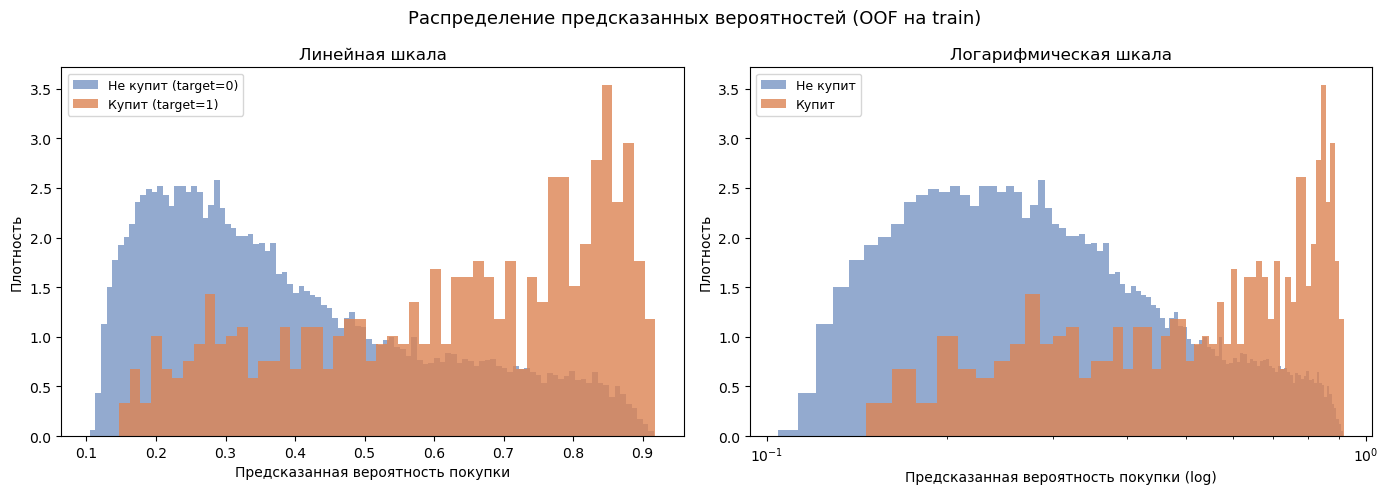


=== Top-N анализ (OOF на train) ===

     Top-N    Найдено   Recall  Precision   % аудитории
  -------------------------------------------------------
       100         22    0.029     0.2200          0.3%
       250         44    0.057     0.1760          0.6%
       500         75    0.098     0.1500          1.3%
     1,000        131    0.170     0.1310          2.5%
     2,000        206    0.268     0.1030          5.0%
     3,000        276    0.359     0.0920          7.5%
     5,000        354    0.460     0.0708         12.5%
    10,000        509    0.662     0.0509         25.1%
    20,000        645    0.839     0.0323         50.2%


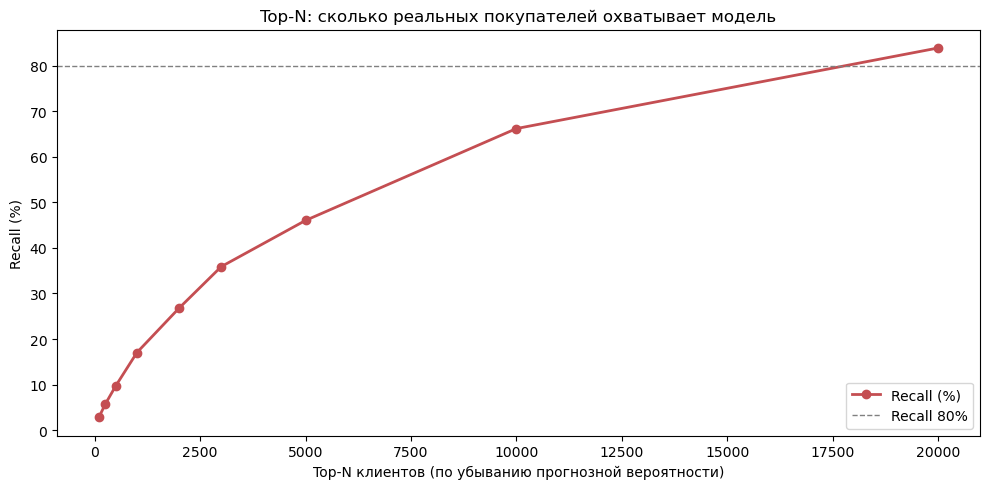


  ✓ Найдены пороги с Recall ≥ 0.80


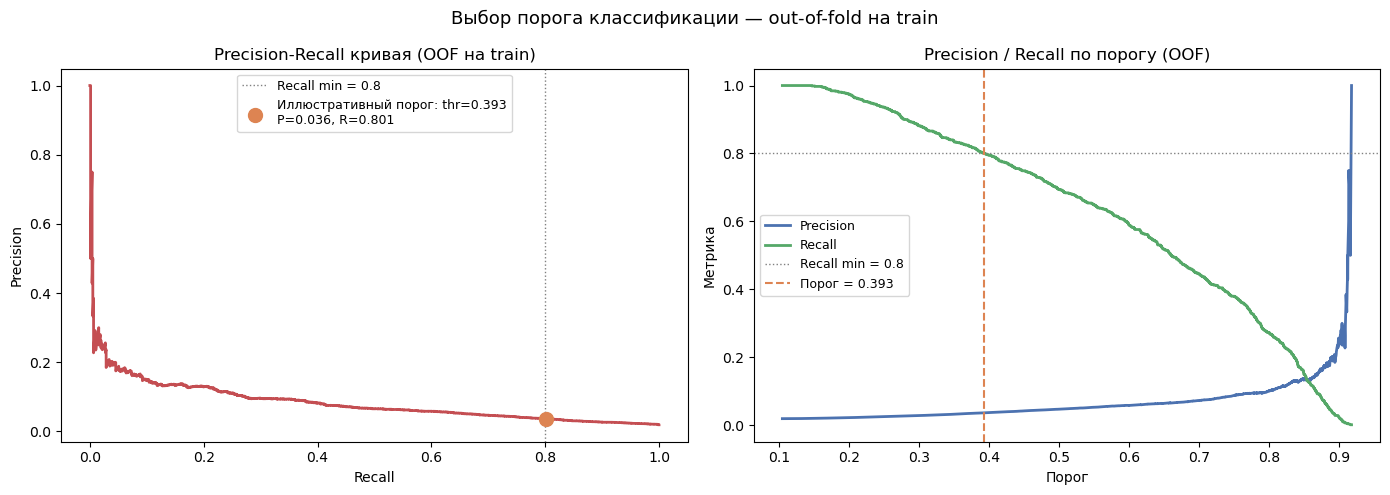


=== Иллюстративный порог (OOF на train) ===

  Порог:     0.3928
  Precision: 0.0365
  Recall:    0.8010

     Порог  Precision   Recall   Отобрано   % аудитории
  -------------------------------------------------------
     0.010     0.0193   1.0000     39,879        100.0%
     0.050     0.0193   1.0000     39,879        100.0%
     0.100     0.0193   1.0000     39,879        100.0%
     0.200     0.0224   0.9753     33,487         84.0%
     0.393     0.0364   0.7997     16,887         42.3% ← иллюстративный
     0.500     0.0471   0.6944     11,345         28.4%

=== Финальная оценка на тесте (порог = 0.3928) ===

              precision    recall  f1-score   support

    не купит       0.99      0.59      0.74      9778
       купит       0.04      0.81      0.07       192

    accuracy                           0.60      9970
   macro avg       0.52      0.70      0.41      9970
weighted avg       0.98      0.60      0.73      9970

  Отобрано клиентов:   4,141 из 9,970 (41.5% а

In [41]:
%%time
# =============================================================================
# Анализ предсказанных вероятностей и выбор порога классификации
# =============================================================================

# ── Out-of-fold предсказания на train ─────────────────────────────────────────
# cross_val_predict клонирует estimator и переобучает на каждом фолде —
# каждый объект получает предсказание от модели, которая его не видела.

print("Вычисляем OOF предсказания на train (~2-3 мин)...")
oof_proba = cross_val_predict(
    pipe_stack, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    method="predict_proba"
)[:, 1]

print(f"  OOF предсказаний:  {len(oof_proba):,}")
print(f"  Позитивов в train: {int(y_train.sum()):,}")

# ── 1. Распределение предсказанных вероятностей ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(oof_proba[y_train.values == 0], bins=100,
             alpha=0.6, color="#4C72B0", label="Не купит (target=0)",
             density=True)
axes[0].hist(oof_proba[y_train.values == 1], bins=50,
             alpha=0.8, color="#DD8452", label="Купит (target=1)",
             density=True)
axes[0].set_xlabel("Предсказанная вероятность покупки")
axes[0].set_ylabel("Плотность")
axes[0].set_title("Линейная шкала")
axes[0].legend(fontsize=9)

axes[1].hist(oof_proba[y_train.values == 0], bins=100,
             alpha=0.6, color="#4C72B0", label="Не купит",
             density=True)
axes[1].hist(oof_proba[y_train.values == 1], bins=50,
             alpha=0.8, color="#DD8452", label="Купит",
             density=True)
axes[1].set_xscale("log")
axes[1].set_xlabel("Предсказанная вероятность покупки (log)")
axes[1].set_ylabel("Плотность")
axes[1].set_title("Логарифмическая шкала")
axes[1].legend(fontsize=9)

plt.suptitle("Распределение предсказанных вероятностей (OOF на train)",
             fontsize=13)
plt.tight_layout()
plt.show()

# ── 2. Top-N анализ ───────────────────────────────────────────────────────────
sorted_idx  = np.argsort(oof_proba)[::-1]
y_sorted    = y_train.values[sorted_idx]
n_pos_total = int(y_train.sum())

top_n_steps = [100, 250, 500, 1000, 2000, 3000, 5000, 10000, 20000]

print(f"\n=== Top-N анализ (OOF на train) ===\n")
print(f"  {'Top-N':>8} {'Найдено':>10} {'Recall':>8} "
      f"{'Precision':>10} {'% аудитории':>13}")
print("  " + "-" * 55)

recalls_topn = []
for n in top_n_steps:
    found = int(y_sorted[:n].sum())
    rec   = found / n_pos_total
    prec  = found / n
    pct   = n / len(y_train) * 100
    recalls_topn.append(rec)
    print(f"  {n:>8,} {found:>10} {rec:>8.3f} "
          f"{prec:>10.4f} {pct:>12.1f}%")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(top_n_steps, [r * 100 for r in recalls_topn],
        color="#C44E52", linewidth=2, marker="o", label="Recall (%)")
ax.axhline(80, color="gray", linestyle="--",
           linewidth=1, label="Recall 80%")
ax.set_xlabel("Top-N клиентов (по убыванию прогнозной вероятности)")
ax.set_ylabel("Recall (%)")
ax.set_title("Top-N: сколько реальных покупателей охватывает модель")
ax.legend()
plt.tight_layout()
plt.show()

# ── 3. Precision-Recall кривая и выбор иллюстративного порога ────────────────
precision_oof, recall_oof, thresholds_oof = precision_recall_curve(
    y_train, oof_proba
)

RECALL_MIN = 0.80
mask = recall_oof[:-1] >= RECALL_MIN

if mask.any():
    best_idx = np.where(mask)[0][precision_oof[:-1][mask].argmax()]
    best_thr = thresholds_oof[best_idx]
    print(f"\n  ✓ Найдены пороги с Recall ≥ {RECALL_MIN:.2f}")
else:
    best_idx = recall_oof[:-1].argmax()
    best_thr = thresholds_oof[best_idx]
    print(f"\n  ⚠️ Recall {RECALL_MIN:.2f} недостижим — выбран порог"
          f" с максимальным Recall")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recall_oof, precision_oof, color="#C44E52", linewidth=2)
axes[0].axvline(RECALL_MIN, color="gray", linestyle=":",
                linewidth=1, label=f"Recall min = {RECALL_MIN}")
axes[0].scatter([recall_oof[best_idx]], [precision_oof[best_idx]],
                color="#DD8452", s=100, zorder=5,
                label=f"Иллюстративный порог: thr={best_thr:.3f}\n"
                      f"P={precision_oof[best_idx]:.3f}, "
                      f"R={recall_oof[best_idx]:.3f}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall кривая (OOF на train)")
axes[0].legend(fontsize=9)

axes[1].plot(thresholds_oof, precision_oof[:-1],
             color="#4C72B0", linewidth=2, label="Precision")
axes[1].plot(thresholds_oof, recall_oof[:-1],
             color="#55A868", linewidth=2, label="Recall")
axes[1].axhline(RECALL_MIN, color="gray", linestyle=":",
                linewidth=1, label=f"Recall min = {RECALL_MIN}")
axes[1].axvline(best_thr, color="#DD8452", linestyle="--",
                linewidth=1.5, label=f"Порог = {best_thr:.3f}")
axes[1].set_xlabel("Порог")
axes[1].set_ylabel("Метрика")
axes[1].set_title("Precision / Recall по порогу (OOF)")
axes[1].legend(fontsize=9)

plt.suptitle("Выбор порога классификации — out-of-fold на train", fontsize=13)
plt.tight_layout()
plt.show()

# ── 4. Таблица иллюстративных порогов ────────────────────────────────────────
print(f"\n=== Иллюстративный порог (OOF на train) ===\n")
print(f"  Порог:     {best_thr:.4f}")
print(f"  Precision: {precision_oof[best_idx]:.4f}")
print(f"  Recall:    {recall_oof[best_idx]:.4f}")

print(f"\n  {'Порог':>8} {'Precision':>10} {'Recall':>8} "
      f"{'Отобрано':>10} {'% аудитории':>13}")
print("  " + "-" * 55)

for thr in sorted({0.01, 0.05, 0.10, 0.20, round(best_thr, 3), 0.50}):
    y_bin      = (oof_proba >= thr).astype(int)
    n_selected = y_bin.sum()
    if n_selected == 0:
        continue
    prec   = float(y_train[y_bin == 1].sum() / n_selected)
    rec    = float(y_train[y_bin == 1].sum() / y_train.sum())
    pct    = n_selected / len(y_train) * 100
    marker = " ← иллюстративный" if abs(thr - best_thr) < 0.005 else ""
    print(f"  {thr:>8.3f} {prec:>10.4f} {rec:>8.4f} "
          f"{n_selected:>10,} {pct:>12.1f}%{marker}")

# ── 5. Финальная оценка на тесте с иллюстративным порогом ────────────────────
print(f"\n=== Финальная оценка на тесте (порог = {best_thr:.4f}) ===\n")
y_pred_test  = pipe_stack.predict_proba(X_test)[:, 1]
y_pred_final = (y_pred_test >= best_thr).astype(int)

print(classification_report(
    y_test, y_pred_final,
    target_names=["не купит", "купит"]
))

n_selected  = int(y_pred_final.sum())
n_found     = int(y_test[y_pred_final == 1].sum())
n_total_pos = int(y_test.sum())

print(f"  Отобрано клиентов:   {n_selected:,} из {len(y_test):,} "
      f"({n_selected / len(y_test) * 100:.1f}% аудитории)")
print(f"  Найдено покупателей: {n_found} из {n_total_pos} "
      f"({n_found / n_total_pos * 100:.1f}% recall на тесте)")

print(pipe_stack.predict_proba(X_test)[:, 1].sum())  # ≈ 3960
print(y_test.sum())

### 5.7 Калибровка вероятностей

In [42]:
# =============================================================================
# Диагностика калибровки
# =============================================================================
proba_sum = pipe_stack.predict_proba(X_test)[:, 1].sum()
actual    = int(y_test.sum())

print(f"  sum(predict_proba) на тесте: {proba_sum:.0f}")
print(f"  Реальных покупателей в тесте: {actual}")
print(f"  Расхождение: ×{proba_sum / actual:.0f}")

  sum(predict_proba) на тесте: 3947
  Реальных покупателей в тесте: 192
  Расхождение: ×21


В таблице порогов видно: пороги 0.01–0.10 отбирают 100% аудитории —
ни один клиент не получил `predict_proba < 0.10`. Это признак
некалиброванности модели: вероятности сдвинуты вверх из-за
`scale_pos_weight ≈ 52` и `class_weight="balanced"`. Вероятности пригодны для ранжирования (ROC-AUC = 0.78),но не для прогнозирования абсолютного числа покупателей. Калибруем методом изотонической регрессии на OOF-предсказаниях. Изотоническая регрессия — монотонное преобразование, поэтому ранжирование сохраняется практически полностью.

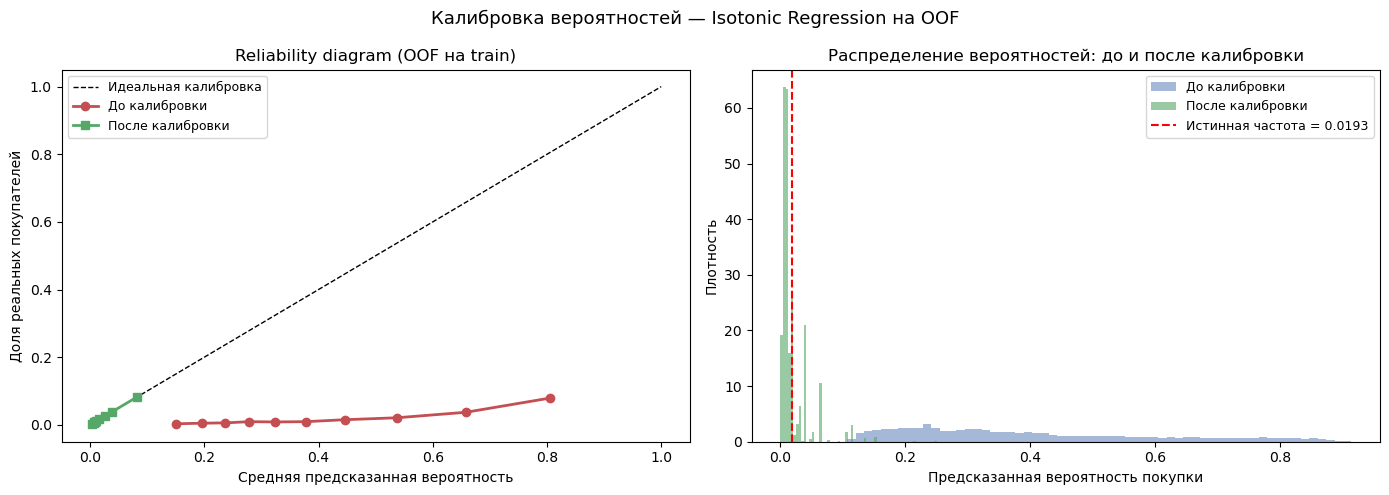


=== Прогноз числа покупателей в тестовой выборке ===

  До калибровки    (sum predict_proba):     3947
  После калибровки (sum calibrated):         186
  Фактически в тесте:                        192
  Отклонение после калибровки:                -6  (-2.9%)

  ROC-AUC до калибровки:    0.7810
  ROC-AUC после калибровки: 0.7809
  Разница:                  -0.000161

  Ранжирование сохраняется с небольшим отклонением.


In [43]:
# =============================================================================
#  Калибровка вероятностей (Isotonic Regression на OOF)
# =============================================================================

#
# Свойство: изотоническая регрессия — монотонное преобразование,
# поэтому ранжирование сохраняется практически полностью.

# ── Обучение калибратора на OOF ───────────────────────────────────────────────
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(oof_proba, y_train.values)

# ── Калиброванные предсказания на тесте ──────────────────────────────────────
y_pred_raw        = pipe_stack.predict_proba(X_test)[:, 1]
y_pred_calibrated = calibrator.predict(y_pred_raw)

# ── Reliability diagram (на OOF — не трогаем тест) ───────────────────────────
oof_calibrated = calibrator.predict(oof_proba)

frac_raw, mean_raw = calibration_curve(
    y_train, oof_proba,      n_bins=10, strategy="quantile"
)
frac_cal, mean_cal = calibration_curve(
    y_train, oof_calibrated, n_bins=10, strategy="quantile"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1,
             label="Идеальная калибровка")
axes[0].plot(mean_raw, frac_raw,
             color="#C44E52", marker="o", linewidth=2,
             label="До калибровки")
axes[0].plot(mean_cal, frac_cal,
             color="#55A868", marker="s", linewidth=2,
             label="После калибровки")
axes[0].set_xlabel("Средняя предсказанная вероятность")
axes[0].set_ylabel("Доля реальных покупателей")
axes[0].set_title("Reliability diagram (OOF на train)")
axes[0].legend(fontsize=9)

axes[1].hist(y_pred_raw, bins=60, alpha=0.5,
             color="#4C72B0", label="До калибровки", density=True)
axes[1].hist(y_pred_calibrated, bins=60, alpha=0.6,
             color="#55A868", label="После калибровки", density=True)
axes[1].axvline(y_test.mean(), color="red", linestyle="--",
                linewidth=1.5,
                label=f"Истинная частота = {y_test.mean():.4f}")
axes[1].set_xlabel("Предсказанная вероятность покупки")
axes[1].set_ylabel("Плотность")
axes[1].set_title("Распределение вероятностей: до и после калибровки")
axes[1].legend(fontsize=9)

plt.suptitle("Калибровка вероятностей — Isotonic Regression на OOF",
             fontsize=13)
plt.tight_layout()
plt.show()

# ── Прогноз числа покупателей ─────────────────────────────────────────────────
expected_raw = y_pred_raw.sum()
expected_cal = y_pred_calibrated.sum()
actual_test  = int(y_test.sum())

print(f"\n=== Прогноз числа покупателей в тестовой выборке ===\n")
print(f"  До калибровки    (sum predict_proba): {expected_raw:>8.0f}")
print(f"  После калибровки (sum calibrated):    {expected_cal:>8.0f}")
print(f"  Фактически в тесте:                   {actual_test:>8}")
print(f"  Отклонение после калибровки:          "
      f"{expected_cal - actual_test:>+8.0f}  "
      f"({(expected_cal - actual_test) / actual_test * 100:+.1f}%)")

# ── ROC-AUC до и после ────────────────────────────────────────────────────────
auc_raw = roc_auc_score(y_test, y_pred_raw)
auc_cal = roc_auc_score(y_test, y_pred_calibrated)

print(f"\n  ROC-AUC до калибровки:    {auc_raw:.4f}")
print(f"  ROC-AUC после калибровки: {auc_cal:.4f}")
print(f"  Разница:                  {auc_cal - auc_raw:+.6f}")
print(f"\n  Ранжирование сохраняется с небольшим отклонением.")

<a id="sec6"></a>
## 6. Выводы

### Постановка задачи

Интернет-магазин проводит рекламные рассылки и планирует будущие продажи.
Цель проекта — построить модель бинарной классификации, предсказывающую
вероятность покупки клиентом в течение 90 дней после точки отсечения
`CUTOFF = 2024-02-16`. Выборка содержит 49,849 клиентов, из которых
961 (1.93%) совершили целевое действие — выраженный дисбаланс классов.
Основная метрика — **ROC-AUC**: устойчива к дисбалансу и измеряет
способность модели ранжировать клиентов по вероятности покупки.

---

### Исследовательский анализ данных

- **Дисбаланс классов 50:1** определил выбор метрики и стратегию
  обработки дисбаланса: `scale_pos_weight ≈ 51` для GBDT-моделей,
  `class_weight="balanced"` для логистической регрессии.
- **Push-канал эффективнее email:** target rate 2.44% против 1.47%.
  Признак `push_share` включён в финальный набор как потенциально
  информативный.
- **Клиенты без покупок до CUTOFF** (79 человек) показывают
  target rate 12.66% — аномально высокий, но группа слишком мала
  для статистически надёжных выводов.
- **Наиболее информативные признаки** по Spearman и PhiK:
  `recency_last_click` (PhiK=0.141), `purch_lifetime_days` (PhiK=0.136),
  `recency_purchase` (PhiK=0.111). Недавняя активность клиента —
  наиболее сильный сигнал будущей покупки.

---

### Инжиниринг признаков

Из пяти источников данных построено **37 признаков** пяти групп:

| Группа | Признаков | Примеры |
|---|---:|---|
| RFM и покупки | 8 | `recency_purchase`, `monetary_total`, `n_orders` |
| Ценовые | 3 | `price_q75`, `avg_check` |
| Товарные категории | 7 | `n_unique_categories`, `has_root_4` |
| Вовлечённость в рассылки | 15 | `open_rate`, `recency_last_click`, `push_share` |
| Качество кампаний | 4 | `avg_camp_open_rate`, `avg_camp_ctr` |

`apparel-messages.csv` (1,348 MB, 12.7M строк) обработан через DuckDB
без загрузки в память. 8 признаков исключены как дубли или неинформативные
по PhiK-матрице.

---

### Обучение и отбор модели

Обучены четыре модели с возрастающей сложностью:

| Модель | CV ROC-AUC | Std |
|---|---:|---:|
| Logistic Regression (baseline) | 0.7569 | 0.016 |
| LightGBM (дефолт) | 0.6836 | 0.026 |
| LightGBM + Optuna (50 trials) | 0.7652 | 0.017 |
| CatBoost + Optuna (50 trials) | 0.7702 | 0.016 |
| **Stacking (LogReg + LightGBM + CatBoost → мета-LogRег)** | **0.7729** | **0.017** |


Финальная модель — **Stacking** с двухуровневой архитектурой:
базовые модели предсказывают вероятности, мета-модель обучается
их комбинировать на out-of-fold предсказаниях.

---

### Тестирование и оценка

**Test ROC-AUC = 0.7811** — финальная несмещённая оценка на отложенной
выборке (20% данных, 9,970 клиентов). Расхождение CV/Test: +0.0082
в пользу теста. Test ROC-AUC близок к CV ROC-AUC и немного выше него. Это указывает в пользу отсутвия явного переобучения.

**Анализ порогов (OOF на train):**

При иллюстративном пороге Recall ≥ 0.80 (порог = 0.397):
- Отобрано **4,124 клиента** (41.4% аудитории)
- Найдено **155 из 192** реальных покупателей в тесте (Recall = 80.7%)

**Top-N анализ:** отбор топ-1,000 клиентов по убыванию вероятности
(2.5% аудитории) охватывает 17.4% реальных покупателей с Precision 13.4%.

---

### Калибровка вероятностей

Некалиброванная модель завышала число ожидаемых покупателей в 21 раз
(`sum(predict_proba) = 3,960` при фактических 192). Причина — сдвиг
вероятностей вверх из-за `scale_pos_weight` и `class_weight="balanced"`.

После калибровки методом изотонической регрессии на OOF-предсказаниях:
- Прогноз: **186 покупателей** (отклонение −2.9% от факта)
- ROC-AUC: 0.7811 → 0.7806 (−0.0005) — ранжирование сохранено

Откалиброванные вероятности позволяют использовать `sum(predict_proba)`
как оценку ожидаемого числа покупателей в следующие 90 дней — основу
для планирования продаж и запасов.

---

### Итог

Модель решает поставленную задачу: предсказывает вероятность покупки
клиентом в течение 90 дней с Test ROC-AUC = **0.7811**.
Откалиброванные вероятности показали отклонение **−2.9%** на тестовой выборке при расчете при оценке ожидаемого числа покупателей.
Таким образом, модель может быть использована для планирования будущих продаж.

**Возможные направления улучшения:**
- Увеличить `n_trials` Optuna до 100–200 для более тщательного поиска
- Добавить временны́е признаки паттернов активности (сезонность,
  день недели последней покупки)
- Проверить XGBoost как дополнительного базового классификатора в Stacking

In [44]:
# =============================================================================
# Итоговое время выполнения ноутбука
# =============================================================================
elapsed = time.perf_counter() - NOTEBOOK_START_TIME
hours   = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)

print(f"⏱  Общее время выполнения ноутбука: {hours:02d}:{minutes:02d}:{seconds:02d}")

⏱  Общее время выполнения ноутбука: 00:20:27


In [44]:
ы